# Project Setup

## Project Details (Add Project Name)

# Project Setup

## Project Details (Add Project Name)


**Dataset:** Claude Generated Loan Data  
**Author:** Chuch  
**Date:** 2026-06-08  
**Objective:** playing around with pandas and completing challenges  
**Status:** In Progress / Complete

## Environment and Imports

In [2]:
# ══════════════════════════════════════════════════════
# Environment Setup
# ══════════════════════════════════════════════════════

# ── Standard Library ──────────────────────────────────
import os
import sys
import warnings
import re

# ── Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Machine Learning ──────────────────────────────────
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display

def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent

repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

import python_style_util as psu
import evaluation_utils as eu
import missingness_viz as mv        # missingess assessment functions
import fix_notebook_prints as fnp

# ══════════════════════════════════════════════════════
# Display Settings
# ══════════════════════════════════════════════════════

%matplotlib inline

# Pandas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')



# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Style Guide

c:\Users\evanr\OneDrive\Desktop\CreditRiskLearning\Core Resources\python_style_util.py:889: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


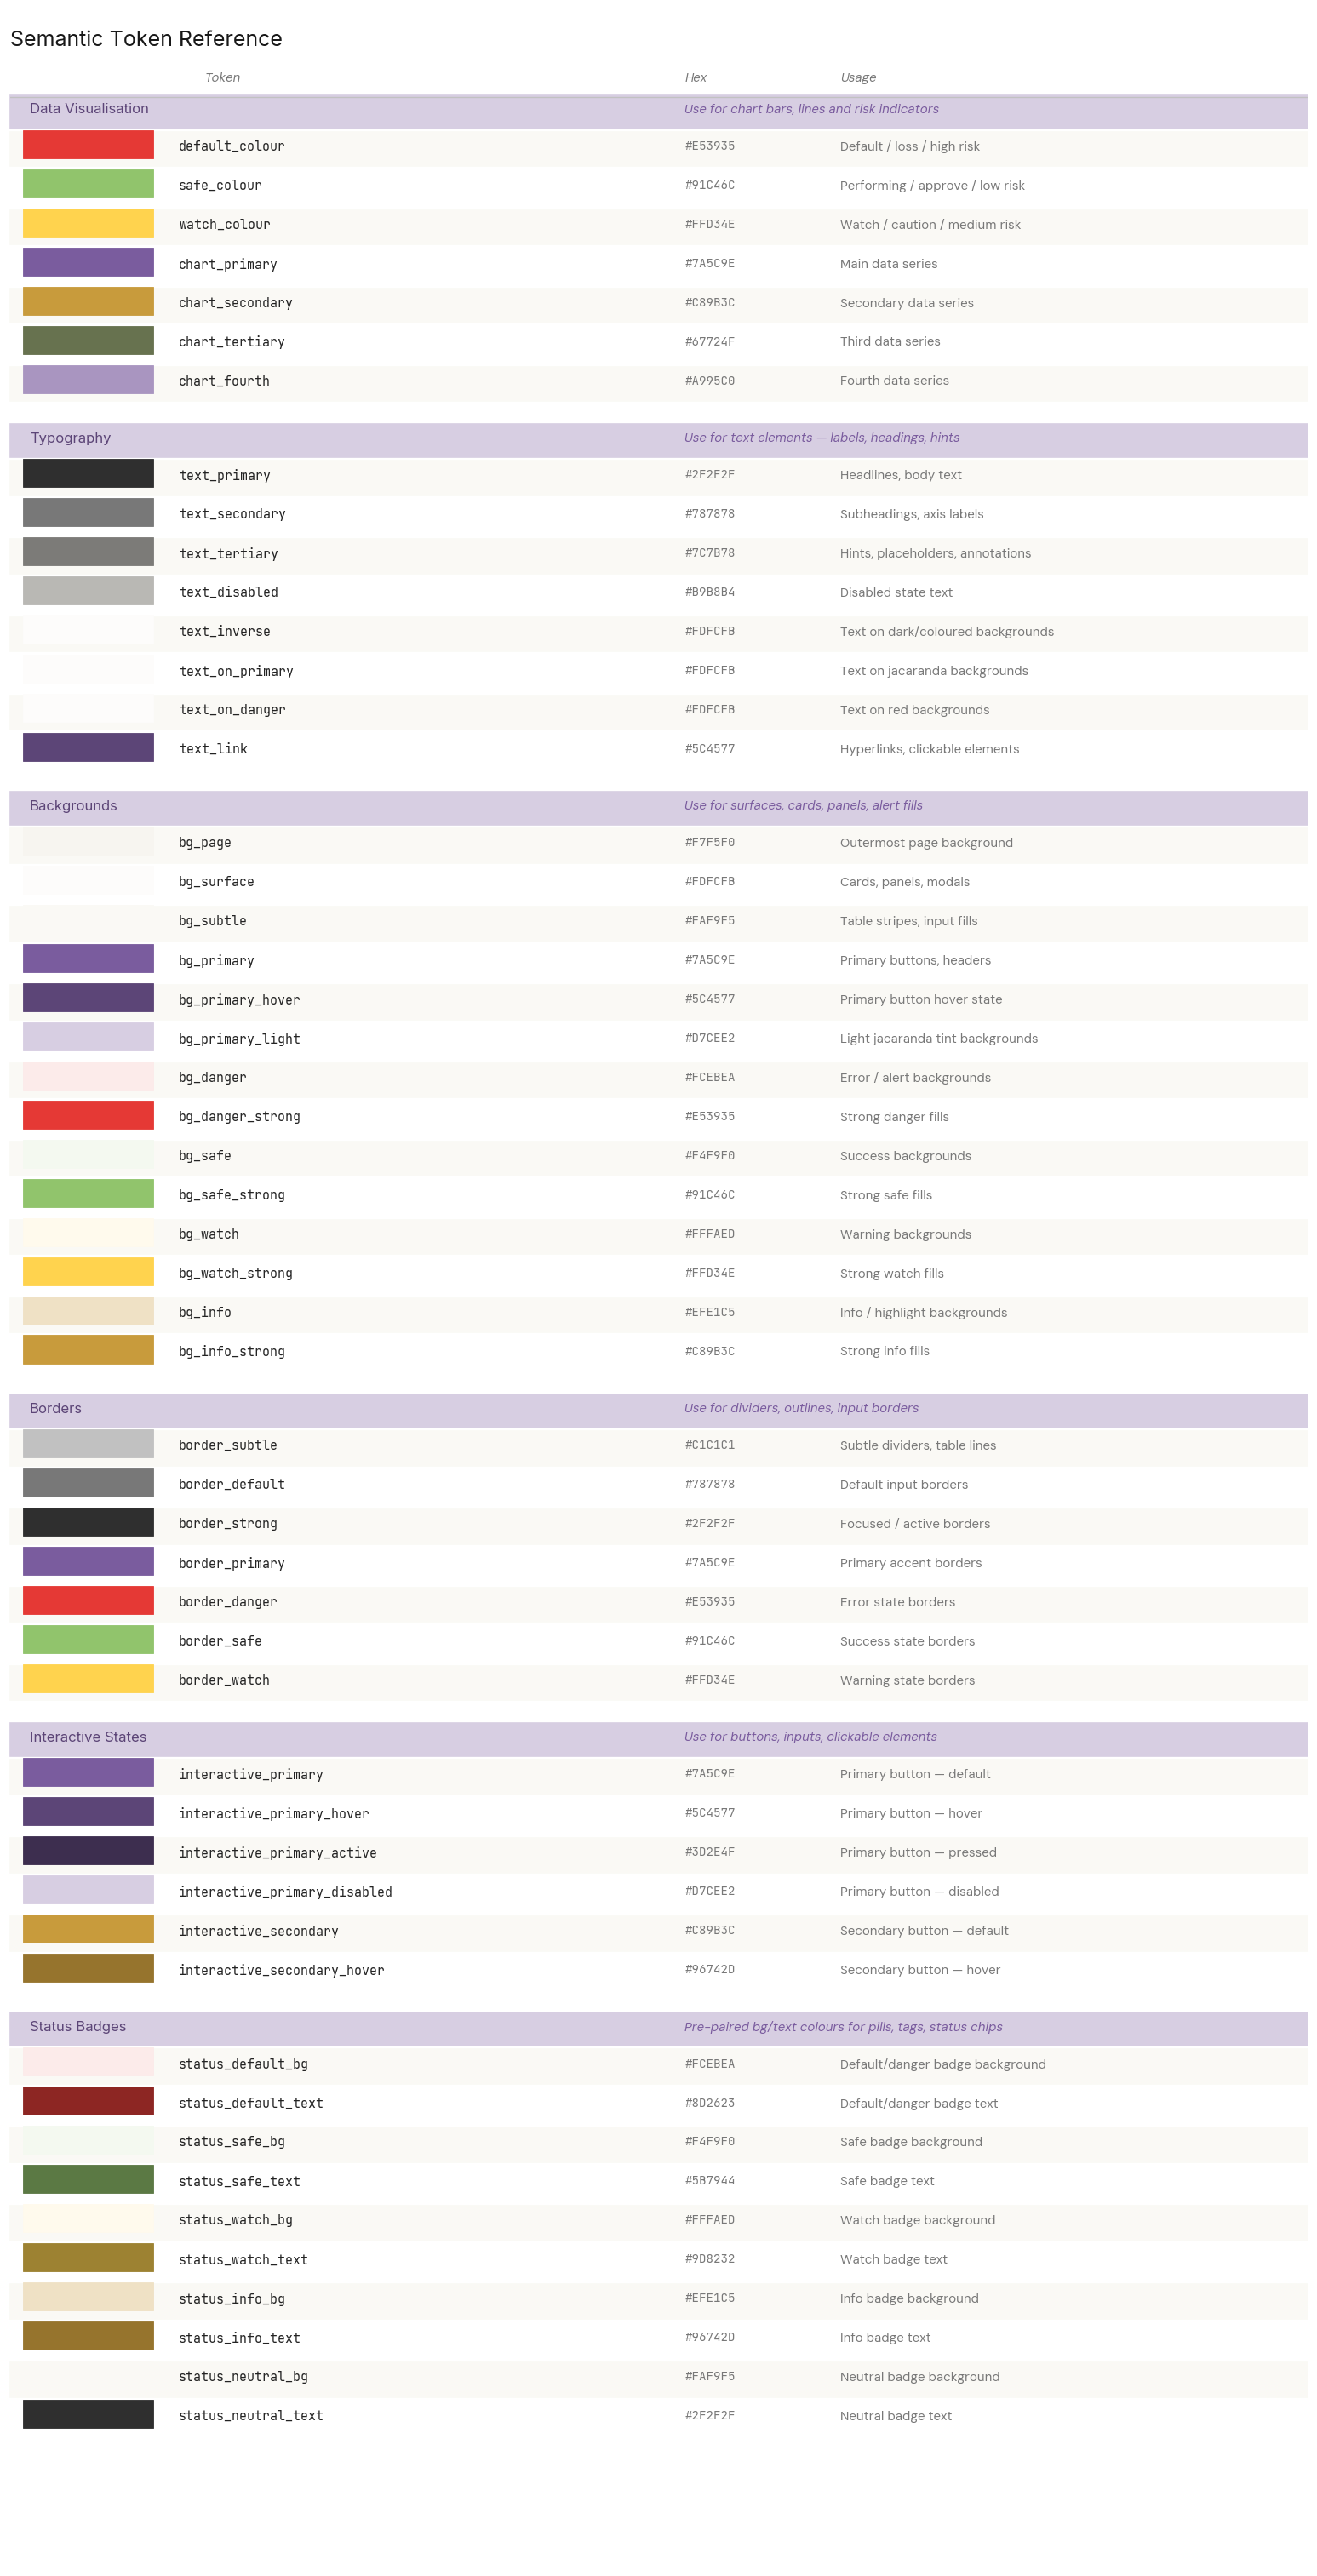

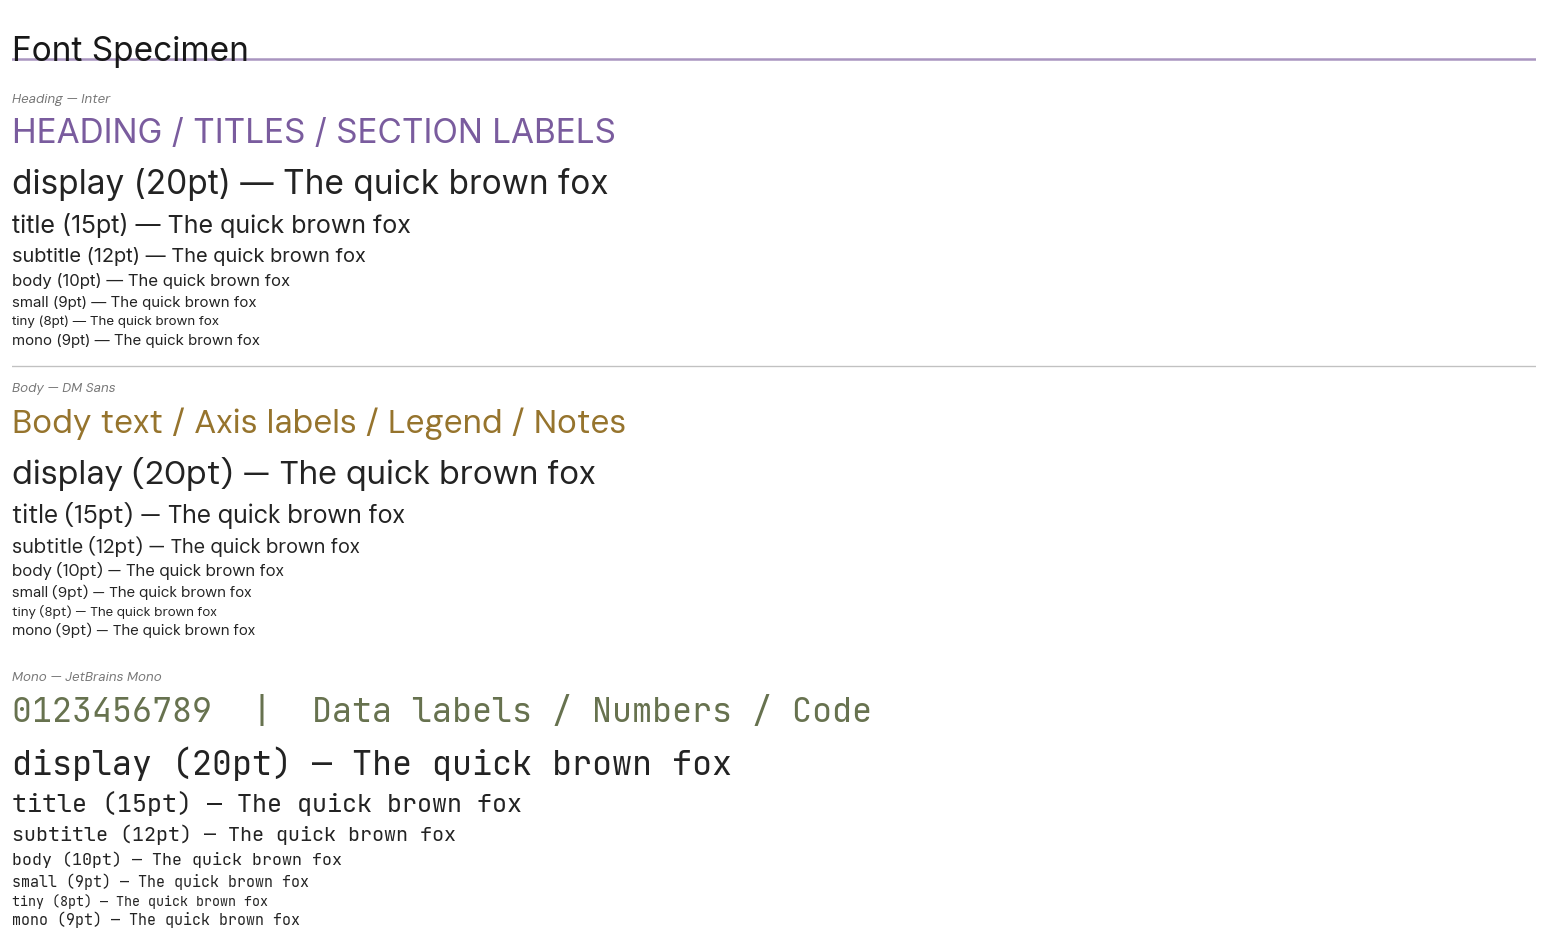

In [3]:
psu.show_tokens()
psu.show_fonts()


In [4]:
# import os

# core = os.path.join(os.path.abspath('..'), 'Core Resources')
# scripts = os.path.join(os.path.abspath('..'), 'Core Resources', 'Scripts')

# print("Core Resources contents:")
# print(os.listdir(core))

# print("\nScripts contents:")
# print(os.listdir(scripts) if os.path.exists(scripts) else "Scripts folder doesn't exist")

## Display Setttings

In [5]:
# --- Pandas ---

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---

np.set_printoptions(
    precision=4,        # decimal places (you have this)
    suppress=True,      # no scientific notation (you have this)
    linewidth=120,      # wrap width (you have this)
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---

%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---

InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---

psu.set_style()

## Data Loading

In [6]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('pandas_practice_notebook.ipynb'))
data_path = os.path.join(base_path)

# Load data
df_borrowers = pd.read_csv('borrowers.csv', sep=',')
df_credit = pd.read_csv('credit_bureau.csv', sep=',')
df_loans = pd.read_csv('loans.csv', sep=',')
df_repayments = pd.read_csv('repayments.csv', sep=',')


# Pandas Practice — Credit Risk Datasets

A task checklist to drill pandas end to end, using the four mock tables in `Practice Datasets/`: `borrowers.csv`, `loans.csv`, `repayments.csv`, `credit_bureau.csv`. They're deliberately messy (mixed casing, mixed date formats, duplicates, missing values, orphan keys, currency/percent strings) so cleaning tasks have real problems to solve — see the `README.md` alongside them for the full list of seeded issues.

**How to use this notebook:** write each answer from scratch in the empty code cell below its task — don't look up a reference solution first. This targets the recognition-vs-generation gap: you can already spot the right answer in a multiple choice list, the gap is producing the syntax cold. If you get stuck, note *why* before checking docs.

Sections roughly follow the study guide sequence, with extra reps on filtering/boolean indexing (requested focus) and on the specific weak spots from your last quiz: `.agg()` column-selector syntax, `pivot_table(aggfunc=...)`, the IQR outlier formula, multi-file `pd.concat()`, and data leakage identification.

## Section 0 — Setup

- [✅] 0.1 Print the `.shape` of each DataFrame to confirm they loaded.

In [7]:
# Task 0.1

print('The borrowers dataset has', df_borrowers.shape[0], 'rows and', df_borrowers.shape[1], 'columns.')

print('The credit dataset has', df_credit.shape[0], 'rows and', df_credit.shape[1], 'columns.')

print('The loans dataset has', df_loans.shape[0], 'rows and', df_loans.shape[1], 'columns.')

print('The repayments dataset has', df_repayments.shape[0], 'rows and', df_repayments.shape[1], 'columns.')


The borrowers dataset has 41 rows and 7 columns.
The credit dataset has 47 rows and 6 columns.
The loans dataset has 55 rows and 8 columns.
The repayments dataset has 90 rows and 6 columns.


## Section 1 — First Look

- [✅] 1.1 Run `.info()` on all four DataFrames. Note which columns have unexpected dtypes (e.g. numeric-looking columns stored as `object`).
- [✅] 1.2 Run `.describe()` on `loans` (numeric only), then again with `include='object'`.
- [✅] 1.3 Print `borrowers.shape`, `borrowers.columns`, `borrowers.dtypes`.
- [✅] 1.4 Run `.value_counts()` on `employment_status`, `loans['purpose']`, `loans['status']`, `repayments['payment_method']`, and `credit_bureau['bankruptcy_flag']`. Write down every distinct spelling/casing variant you find for each.
- [✅] 1.5 Compare `borrowers['borrower_id'].nunique()` to `len(borrowers)` — what does the gap tell you?
- [✅] 1.6 For each DataFrame, run `.isnull().sum().sort_values(ascending=False)` to rank columns by missingness.

In [8]:
# Task 1.1
print('BORROWERS DATASET INFO\n')

df_borrowers.info()

# dtypes check out for each columns - not flagging anything

print('\n\n')

print('CREDIT DATASET INFO\n')

df_credit.info()

# total_debt as a string - need to look at this further

print('\n\n')

print('LOANS DATASET INFO\n')

df_loans.info()

# interest_rate as a string - also need to look at this further

print('\n\n')

print('REPAYMENTS DATASET INFO\n')

df_repayments.info()

# these all look fine

BORROWERS DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   borrower_id        41 non-null     str    
 1   full_name          41 non-null     str    
 2   age                40 non-null     float64
 3   annual_income      33 non-null     float64
 4   employment_status  41 non-null     str    
 5   state              41 non-null     str    
 6   credit_score       39 non-null     float64
dtypes: float64(3), str(4)
memory usage: 2.4 KB



CREDIT DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   borrower_id              47 non-null     str    
 1   report_date              47 non-null     str    
 2   num_open_accounts        41 non-null     float64
 3   total_debt     

In [9]:
# Task 1.2


print('LOANS DATASET describe (NUMERIC)\n')

df_loans.describe(include='number')

print('\n')

print('LOANS DATASET describe (OBJECT)\n')

df_loans.describe(include='object')

LOANS DATASET describe (NUMERIC)



,loan_amount,term_months
count,52.00,55.00
mean,15419.23,36.44
std,9272.94,14.96
min,-9000.00,12.00
25%,8875.00,24.00
50%,13400.00,36.00
75%,21050.00,48.00
max,40000.00,60.00




LOANS DATASET describe (OBJECT)



C:\Users\evanr\AppData\Local\Temp\ipykernel_16856\2879102623.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_loans.describe(include='object')


,loan_id,borrower_id,interest_rate,purpose,issue_date,status
count,55,55,53,55,55,55
unique,55,42,53,10,55,8
top,L1001,B001,12.5%,credit_card,2023-01-15,Current
freq,1,2,1,9,1,31


In [10]:
# Task 1.3
print('Shape of the borrowers dataset: ', df_borrowers.shape, '\n\n')

print('List of columns in the borrowers dataset:\n\n', df_borrowers.columns, '\n\n')

print('List of datatypes in the borrowers dataset:\n ', df_borrowers.dtypes)



Shape of the borrowers dataset:  (41, 7) 


List of columns in the borrowers dataset:

 Index(['borrower_id', 'full_name', 'age', 'annual_income', 'employment_status',
       'state', 'credit_score'],
      dtype='str') 


List of datatypes in the borrowers dataset:
  borrower_id              str
full_name                str
age                  float64
annual_income        float64
employment_status        str
state                    str
credit_score         float64
dtype: object


In [11]:
# Task 1.4

df_borrowers['employment_status'].value_counts()

# distinct casing: 'employed', 'Employed', 'EMPLOYED', 'Unemployed', 'unemployed', 'self-employed', 'Self-employed', 'RETIRED', 'retired'

df_loans['purpose'].value_counts()

# distinct casing: 'home_improvement', 'Home Improvement', debt_consolidation, Debt Consolidation , Small Business, small_business, other, Other, Credit Card, credit_card

df_loans['status'].value_counts()

# distinct casing: Current, current, DEFAULT, Default, default, Paid Off, Paid off

df_repayments['payment_method'].value_counts()

# distinct casing: ACH, ach, check, Check, Credit Card, credit card, Wire, wire transfer

df_credit['bankruptcy_flag'].value_counts()

# distinct casing: N, No, Yes, Y

employment_status
Employed         12
employed          7
Self-Employed     5
Retired           5
EMPLOYED          3
Unemployed        3
unemployed        3
self-employed     1
Self-employed     1
retired           1
Name: count, dtype: int64

purpose
credit_card           9
debt_consolidation    8
other                 8
small_business        8
home_improvement      6
Other                 5
Home Improvement      4
Debt Consolidation    3
Small Business        2
Credit Card           2
Name: count, dtype: int64

status
Current     31
current      9
Late         5
DEFAULT      3
Paid Off     3
Default      2
default      1
Paid off     1
Name: count, dtype: int64

payment_method
ACH              29
check            13
Check            11
Credit Card      10
credit card       8
ach               7
Wire              7
wire transfer     5
Name: count, dtype: int64

bankruptcy_flag
N      14
No     12
0       9
Yes     8
Y       3
1       1
Name: count, dtype: int64

In [12]:
# Task 1.5

df_borrowers['borrower_id'].nunique()

len(df_borrowers)

# there must be a duplicate borrower in there

df_borrowers['borrower_id'].value_counts()

# B003 in there twice

df_borrowers[df_borrowers['borrower_id']=='B003']

# Can confirm - "Robert Williams is in there twice"


40

41

borrower_id
B003    2
B001    1
B002    1
B004    1
B005    1
B006    1
B007    1
B008    1
B009    1
B010    1
B011    1
B012    1
B013    1
B014    1
B015    1
B016    1
B017    1
B018    1
B019    1
B020    1
B021    1
B022    1
B023    1
B024    1
B025    1
B026    1
B027    1
B028    1
B029    1
B030    1
B031    1
B032    1
B033    1
B034    1
B035    1
B036    1
B037    1
B038    1
B039    1
B040    1
Name: count, dtype: int64

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00


In [13]:
# Task 1.6

print('BORROWERS')

df_borrowers.isnull().sum().sort_values(ascending=False)

print('CREDIT')

df_credit.isnull().sum().sort_values(ascending=False)

print('LOANS')

df_loans.isnull().sum().sort_values(ascending=False)

print('REPAYMENTS')

df_repayments.isnull().sum().sort_values(ascending=False)


BORROWERS


annual_income        8
credit_score         2
age                  1
full_name            0
borrower_id          0
employment_status    0
state                0
dtype: int64

CREDIT


num_open_accounts          6
total_debt                 4
report_date                0
borrower_id                0
delinquencies_last_2yrs    0
bankruptcy_flag            0
dtype: int64

LOANS


loan_amount      3
interest_rate    2
borrower_id      0
loan_id          0
term_months      0
purpose          0
issue_date       0
status           0
dtype: int64

REPAYMENTS


amount_paid       17
payment_id         0
loan_id            0
payment_date       0
payment_method     0
days_late          0
dtype: int64

## Section 2 — Filtering & Boolean Indexing (extra reps)

- [✅] 2.1 Select `full_name` and `credit_score` from `borrowers` as a DataFrame (not two separate Series) — remember the double-bracket rule.
- [✅] 2.2 Build a boolean mask for `credit_score > 700`, print the mask on its own first, then use it to filter `borrowers`.
- [✅] 2.3 Do the same filter again using `.loc[]` syntax explicitly.
- [✅] 2.4 Filter `loans` for `loan_amount > 20000` **and** `term_months == 36`. Remember: `&`, not `and`, and each condition wrapped in parentheses.
- [✅] 2.5 Filter `loans` for `purpose` equal to `'other'` **or** `'small_business'` using `|`, then rewrite the same filter using `.isin()`.
- [✅] 2.6 Replicate task 2.4 using `df.query()` instead of boolean masks.
- [✅] 2.7 Filter `repayments` down to the problem rows: `amount_paid` is negative **or** missing. (Hint: you'll need `.isnull()` combined with a comparison.)
- [✅] 2.8 Take the `credit_score > 700` filtered subset from 2.2 and add a new column `high_score_flag = 1` to it using `.loc[]` correctly, so it does **not** raise a `SettingWithCopyWarning`.
- [✅] 2.9 Use `.str.contains()` to find every row in `borrowers` where `state` contains `'New'` (should catch `'New York'` regardless of what else is in the column).
- [✅] 2.10 Select the first 10 rows and first 3 columns of `loans` two ways: once with `.iloc[]`, once with `.loc[]`. Confirm both give the same result.
- [✅] 2.11 Filter `borrowers` for implausible ages: `age < 0` or `age > 100`. How many rows does this catch?
- [✅] 2.12 Filter `loans` to only the rows belonging to borrowers from `'TX'` or `'CA'` — first collect the matching `borrower_id`s from `borrowers` using `.isin()` on `state`, then filter `loans` using `.isin()` on that list of ids.

In [14]:
# Task 2.1
df = df_borrowers[['credit_score', 'full_name']]

print(df.columns)

df.head(5)

Index(['credit_score', 'full_name'], dtype='str')


,credit_score,full_name
0,712.00,James Smith
1,688.00,Mary Johnson
2,745.00,Robert Williams
3,601.00,Patricia Brown
4,559.00,Michael Jones


In [15]:
# Task 2.2
mask = df['credit_score'] > 700

print(mask.head(10) if hasattr(mask, "head") else mask)

0     True
1    False
2     True
3    False
4    False
5     True
6    False
7     True
8     True
9    False
Name: credit_score, dtype: bool


In [16]:
# Task 2.3

result = df.loc[mask, ['credit_score']]

print(result.head(10) if hasattr(result, "head") else result)



    credit_score
0  712.00       
2  745.00       
5  780.00       
7  714.00       
8  745.00       
11 760.00       
12 701.00       
18 999.00       
21 705.00       
22 733.00       


In [17]:
# Task 2.4


big_long_loans_df = df_loans[(df_loans['loan_amount'] > 20000) & (df_loans['term_months'] == 60)].copy()

df_loans.head(5)

print(big_long_loans_df.head(10) if hasattr(big_long_loans_df, "head") else big_long_loans_df)

# Has a few loans in this one


big_long_loans_df = df_loans[(df_loans['loan_amount'] > 20000) & (df_loans['term_months'] == 36)].copy()

df_loans.head(5)

print(big_long_loans_df.head(10) if hasattr(big_long_loans_df, "head") else big_long_loans_df)

# No loans in this frame

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
0,L1001,B001,15000.00,12.5%,36,debt_consolidation,2023-01-15,Current
1,L1002,B002,8000.00,9.2,24,credit_card,01/22/2023,current
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
3,L1004,B004,12000.00,11.0,36,Debt Consolidation,2023-02-20,Late
4,L1005,B005,5000.00,18.5%,12,other,2023/03/01,DEFAULT


   loan_id borrower_id  loan_amount interest_rate  term_months  \
2   L1003   B003       25000.00      15.8%         60            
5   L1006   B006       30000.00       10.2         60            
10  L1011   B011       40000.00        9.8         60            
20  L1021   B021       27000.00       9.5%         60            
26  L1027   B027       35000.00       8.9%         60            
33  L1034   B033       26800.00        9.1         60            
40  L1041   B040       31000.00       9.4%         60            
46  L1047   B011       28000.00       9.9%         60            
52  L1053   B027       32500.00       8.7%         60            

   purpose           issue_date   status     
2   home_improvement  15-Feb-2023   Current  
5     small_business   03/10/2023   Current  
10    small_business   2023-04-10   Current  
20  home_improvement   2023-06-01  Paid Off  
26    small_business   2023-07-01   Current  
33  home_improvement   2023-08-01   Current  
40  Home Improvem

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
0,L1001,B001,15000.00,12.5%,36,debt_consolidation,2023-01-15,Current
1,L1002,B002,8000.00,9.2,24,credit_card,01/22/2023,current
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
3,L1004,B004,12000.00,11.0,36,Debt Consolidation,2023-02-20,Late
4,L1005,B005,5000.00,18.5%,12,other,2023/03/01,DEFAULT


Empty DataFrame
Columns: [loan_id, borrower_id, loan_amount, interest_rate, term_months, purpose, issue_date, status]
Index: []


In [18]:
# Task 2.5

print(df_loans.head(10) if hasattr(df_loans, "head") else df_loans)

purpose_subgroup = df_loans[(df_loans['purpose'] == 'other') | (df_loans['purpose'] == 'small_business')]

print(purpose_subgroup.head(10) if hasattr(purpose_subgroup, "head") else purpose_subgroup)

purpose_subgroup_2 = df_loans['purpose'].isin(['other', 'small_business'])

print(purpose_subgroup_2.head(10) if hasattr(purpose_subgroup_2, "head") else purpose_subgroup_2)

# so one filters and returns a df with the rows and the .isin() returns a boolean column? might need this one explained to me 

  loan_id borrower_id  loan_amount interest_rate  term_months  \
0  L1001   B001       15000.00      12.5%         36            
1  L1002   B002        8000.00        9.2         24            
2  L1003   B003       25000.00      15.8%         60            
3  L1004   B004       12000.00       11.0         36            
4  L1005   B005        5000.00      18.5%         12            
5  L1006   B006       30000.00       10.2         60            
6  L1007   B007            NaN        8.5         36            
7  L1008   B008       18000.00      13.4%         48            
8  L1009   B009        9500.00       14.0         24            
9  L1010   B010        7000.00      19.9%         12            

  purpose             issue_date   status     
0  debt_consolidation   2023-01-15   Current  
1         credit_card   01/22/2023   current  
2    home_improvement  15-Feb-2023   Current  
3  Debt Consolidation   2023-02-20      Late  
4               other   2023/03/01   DEFAULT  
5 

In [19]:
# Task 2.6

df_loans.query("loan_amount > 20000 and  term_months == 36")

# doing a second one so there is some kind of output

df_loans.query("loan_amount > 20000 and  term_months == 60")




,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
5,L1006,B006,30000.00,10.2,60,small_business,03/10/2023,Current
10,L1011,B011,40000.00,9.8,60,small_business,2023-04-10,Current
20,L1021,B021,27000.00,9.5%,60,home_improvement,2023-06-01,Paid Off
26,L1027,B027,35000.00,8.9%,60,small_business,2023-07-01,Current
33,L1034,B033,26800.00,9.1,60,home_improvement,2023-08-01,Current
40,L1041,B040,31000.00,9.4%,60,Home Improvement,08/30/2023,Current
46,L1047,B011,28000.00,9.9%,60,home_improvement,2023/09/20,Current
52,L1053,B027,32500.00,8.7%,60,small_business,2023/10/15,Current


In [20]:
# Task 2.7

problem_rows = df_repayments[(df_repayments['amount_paid'] <= 0) | (df_repayments['amount_paid'].isnull())]

problem_rows.head(10)

,payment_id,loan_id,payment_date,amount_paid,payment_method,days_late
6,P00007,L1003,2023-04-15,NaN,credit card,5
10,P00011,L1005,2023-05-01,NaN,Check,45
14,P00015,L1007,2023-03-15,NaN,Wire,0
19,P00020,L1010,2023-05-05,-150.00,check,0
23,P00024,L1012,10-May-2023,NaN,ACH,0
27,P00028,L1015,2023-06-01,NaN,Credit Card,0
33,P00034,L1019,06/20/2023,NaN,credit card,0
40,P00041,L1024,15-Jul-2023,NaN,Credit Card,0
47,P00048,L1028,2023-08-05,NaN,Check,0
50,P00051,L1030,2023-08-11,-200.00,check,0


In [21]:
# Task 2.8

df_borrowers_copy = df_borrowers.copy()

df_borrowers_copy['mask'] = df_borrowers_copy['credit_score'] > 700

df_borrowers_copy.head(10)

df_borrowers_copy['high_score_flag'] = df_borrowers_copy['mask'].astype(int)

df_borrowers_copy.drop(columns='mask')

df_borrowers_copy.head(10)

# confused if this is whats being asked - added the 1 and 0 column but not using .loc() - also referring to a "filtered subset" with credit score >700 would mean every single line would get a 1 - so i just used to mask and created another column with .astype(int)

# walk me through the actual solution you wanted when you check it - i guess this is how analysis works - using the tools you know to acheive your desired outcome


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,mask
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,True
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,True
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,False
5,B006,Linda Garcia,38.00,97000.00,self-employed,TX,780.00,True
6,B007,William Miller,60.00,NaN,Retired,FL,690.00,False
7,B008,Elizabeth Davis,45.00,73000.00,Employed,Florida,714.00,True
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,True
9,B009,David Rodriguez,31.00,56000.00,employed,CA,633.00,False


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,high_score_flag
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,1
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,0
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,1
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,0
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,0
5,B006,Linda Garcia,38.00,97000.00,self-employed,TX,780.00,1
6,B007,William Miller,60.00,NaN,Retired,FL,690.00,0
7,B008,Elizabeth Davis,45.00,73000.00,Employed,Florida,714.00,1
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,1
9,B009,David Rodriguez,31.00,56000.00,employed,CA,633.00,0


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,mask,high_score_flag
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,True,1
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False,0
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,True,1
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False,0
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,False,0
5,B006,Linda Garcia,38.00,97000.00,self-employed,TX,780.00,True,1
6,B007,William Miller,60.00,NaN,Retired,FL,690.00,False,0
7,B008,Elizabeth Davis,45.00,73000.00,Employed,Florida,714.00,True,1
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,True,1
9,B009,David Rodriguez,31.00,56000.00,employed,CA,633.00,False,0


In [22]:
# Task 2.9

df_borrowers['new_state_borrowers'] = df_borrowers['state'].str.contains('New')

print(df_borrowers[df_borrowers['new_state_borrowers'] == True])

df_borrowers.head(5)

   borrower_id full_name       age   annual_income employment_status  \
4   B005        Michael Jones 25.00 41000.00        Unemployed         
16  B016         Sarah Thomas 44.00 59000.00          Employed         
33  B033           Paul Allen 40.00 84500.00          Employed         

   state      credit_score  new_state_borrowers  
4   New York 559.00         True                 
16  New York 682.00         True                 
33  New York 741.00         True                 


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,True


In [23]:
# Task 2.10

df_loans.index.dtype

df_loans.loc[0:9]

df_loans.iloc[0:10]

dtype('int64')

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
0,L1001,B001,15000.00,12.5%,36,debt_consolidation,2023-01-15,Current
1,L1002,B002,8000.00,9.2,24,credit_card,01/22/2023,current
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
3,L1004,B004,12000.00,11.0,36,Debt Consolidation,2023-02-20,Late
4,L1005,B005,5000.00,18.5%,12,other,2023/03/01,DEFAULT
5,L1006,B006,30000.00,10.2,60,small_business,03/10/2023,Current
6,L1007,B007,NaN,8.5,36,credit_card,2023-03-15,Paid Off
7,L1008,B008,18000.00,13.4%,48,Home Improvement,15-Mar-2023,current
8,L1009,B009,9500.00,14.0,24,debt_consolidation,2023-04-01,Current
9,L1010,B010,7000.00,19.9%,12,other,04/05/2023,default


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
0,L1001,B001,15000.00,12.5%,36,debt_consolidation,2023-01-15,Current
1,L1002,B002,8000.00,9.2,24,credit_card,01/22/2023,current
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
3,L1004,B004,12000.00,11.0,36,Debt Consolidation,2023-02-20,Late
4,L1005,B005,5000.00,18.5%,12,other,2023/03/01,DEFAULT
5,L1006,B006,30000.00,10.2,60,small_business,03/10/2023,Current
6,L1007,B007,NaN,8.5,36,credit_card,2023-03-15,Paid Off
7,L1008,B008,18000.00,13.4%,48,Home Improvement,15-Mar-2023,current
8,L1009,B009,9500.00,14.0,24,debt_consolidation,2023-04-01,Current
9,L1010,B010,7000.00,19.9%,12,other,04/05/2023,default


In [24]:
# Task 2.11

implausible_ages = df_borrowers[(df_borrowers['age'] < 0) | (df_borrowers['age'] > 100)]

implausible_ages.head(5)

# catches 2 rows - a smell a hint of data entry problems

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
10,B010,Barbara Martinez,-5.00,39000.00,Unemployed,TX,568.00,False
21,B021,Daniel Lee,151.00,58000.00,Retired,FL,705.00,False


In [25]:
# Task 2.12
tx_and_ca_borrowers = df_borrowers[(df_borrowers['state'].isin(['TX','CA']))]

tx_and_ca_borrowers.head(50)

tx_and_ca_loans = df_loans[df_loans['borrower_id'].isin(tx_and_ca_borrowers['borrower_id'])]

tx_and_ca_loans.head(50)

# Sanity Check

tx_and_ca_borrowers['borrower_id'].nunique()
tx_and_ca_loans['borrower_id'].nunique()

df_borrowers.head(5)

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
5,B006,Linda Garcia,38.00,97000.00,self-employed,TX,780.00,False
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
9,B009,David Rodriguez,31.00,56000.00,employed,CA,633.00,False
10,B010,Barbara Martinez,-5.00,39000.00,Unemployed,TX,568.00,False
14,B014,Jessica Wilson,27.00,48000.00,employed,CA,644.00,False
17,B017,Charles Taylor,39.00,NaN,unemployed,TX,540.00,False
18,B018,Karen Moore,50.00,84000.00,EMPLOYED,CA,999.00,False
22,B022,Lisa Perez,42.00,77000.00,Self-Employed,TX,733.00,False


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
0,L1001,B001,15000.00,12.5%,36,debt_consolidation,2023-01-15,Current
2,L1003,B003,25000.00,15.8%,60,home_improvement,15-Feb-2023,Current
5,L1006,B006,30000.00,10.2,60,small_business,03/10/2023,Current
8,L1009,B009,9500.00,14.0,24,debt_consolidation,2023-04-01,Current
9,L1010,B010,7000.00,19.9%,12,other,04/05/2023,default
13,L1014,B014,14500.00,12.0,36,debt_consolidation,04/22/2023,Current
16,L1017,B017,8800.00,17.3%,24,other,2023-05-12,Late
17,L1018,B018,16500.00,13.0,36,credit_card,12-May-2023,current
21,L1022,B022,19500.00,14.6,48,small_business,06/08/2023,Current
22,L1023,B023,7200.00,18.0%,12,Other,2023-06-15,DEFAULT


15

15

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,True


## Section 3 — Cleaning Messy Data

These map directly onto the issues seeded in the README.

- [✅] 3.1 Strip leading/trailing whitespace from `full_name` and convert to consistent title case.
- [✅] 3.2 Standardize `employment_status` down to exactly four values: `Employed`, `Unemployed`, `Self-Employed`, `Retired` — regardless of the casing in the raw data.
- [✅] 3.3 Standardize `state` to two-letter abbreviations only (map full names like `'California'` → `'CA'`).
- [✅] 3.4 Find and drop the exact duplicate borrower row (`B003`).
- [✅] 3.5 Decide how to handle the invalid ages found in 2.11 (cap, null out, or drop) and implement it. Write one sentence justifying your choice.
- [✅] 3.6 Flag any `credit_score` outside the valid 300–850 range and set those values to `NaN`.
- [✅] 3.7 Parse `loans['issue_date']` and `repayments['payment_date']` — both have at least four different date formats mixed in the same column — into proper `datetime64` columns.
- [✅] 3.8 Clean `interest_rate`: strip the `%` sign where present, then cast the whole column to `float`.
- [✅] 3.9 Handle the negative `loan_amount` value(s) — decide and implement a treatment, with a one-sentence justification.
- [✅] 3.10 Standardize `purpose` and `status` in `loans` to consistent casing/spacing (e.g. one canonical spelling of `debt_consolidation`, `Current`, `Default`, etc).
- [✅] 3.11 Standardize `payment_method` in `repayments` the same way.
- [✅] 3.12 Clean `total_debt` in `credit_bureau`: strip `$` and `,`, then cast to `float`.
- [✅] 3.13 Normalize `bankruptcy_flag` to a proper boolean column (`Y`/`Yes`/`1` → `True`, `N`/`No`/`0` → `False`).
- [✅] 3.14 Find and handle the duplicate repayment on loan `L1001` (same period billed twice).

In [26]:
# Task 3.1
df_borrowers.head(5)

df_borrowers['full_name'] = df_borrowers['full_name'].str.strip()

df_borrowers['full_name'] = df_borrowers['full_name'].str.title()

df_borrowers.head(5)

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,True


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,True


In [27]:
# Task 3.2

# Initial checks

df_borrowers.head(5)

df_borrowers['employment_status'].nunique()

df_borrowers['employment_status'].value_counts()

# Replacing values - not sure if this is the most efficient way but oh well

df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('employed', 'Employed')
df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('EMPLOYED', 'Employed')

df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('unemployed', 'Unemployed')

df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('self-employed', 'Self-Employed')
df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('Self-employed', 'Self-Employed')

df_borrowers['employment_status'] = df_borrowers['employment_status'].replace('retired', 'Retired')

# Checking results

df_borrowers['employment_status'].value_counts()


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,employed,California,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,EMPLOYED,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,New York,559.00,True


10

employment_status
Employed         12
employed          7
Self-Employed     5
Retired           5
EMPLOYED          3
Unemployed        3
unemployed        3
self-employed     1
Self-employed     1
retired           1
Name: count, dtype: int64

employment_status
Employed         22
Self-Employed     7
Unemployed        6
Retired           6
Name: count, dtype: int64

In [28]:
# Task 3.3

print(df_borrowers['state'].value_counts())

state_list = df_borrowers['state'].value_counts().index.tolist()

needs_abbreviation = []

for state in state_list:
    
    if len(state) > 2:
        
        needs_abbreviation.append(state)
        
print(needs_abbreviation.head(10) if hasattr(needs_abbreviation, "head") else needs_abbreviation)

abbreviation_dict = {'New York' : 'NY', 'California' : 'CA', 'Florida' : 'FL', 'Washington' : 'WA', 'Illinois' : 'IL'}

df_borrowers['state'] = df_borrowers['state'].replace(abbreviation_dict)
    
print(df_borrowers['state'].value_counts())

# FUCKING BANG - I AM LEARNING

state
TX            9
CA            7
NY            4
New York      3
FL            3
WA            3
OR            3
IL            3
California    2
Florida       2
Washington    1
Illinois      1
Name: count, dtype: int64
['New York', 'California', 'Florida', 'Washington', 'Illinois']
state
CA    9
TX    9
NY    7
FL    5
WA    4
IL    4
OR    3
Name: count, dtype: int64


In [29]:
# Task 3.4

df_borrowers.head(5)

df_borrowers_duplicate = df_borrowers[df_borrowers['borrower_id'] == 'B003']

df_borrowers_duplicate.head(4)

df_borrowers = df_borrowers.drop(df_borrowers.index[8])

df_borrowers_duplicate = df_borrowers[df_borrowers['borrower_id'] == 'B003']

df_borrowers_duplicate.head(4)


# DONE - not sure if this is the bet method dropping by specific index number though - if there is a proper function for this please let me know

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
0,B001,James Smith,34.00,62000.00,Employed,CA,712.00,False
1,B002,Mary Johnson,29.00,NaN,Employed,CA,688.00,False
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
3,B004,Patricia Brown,52.00,54000.00,Employed,NY,601.00,False
4,B005,Michael Jones,25.00,41000.00,Unemployed,NY,559.00,True


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False
8,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
2,B003,Robert Williams,41.00,88000.00,Self-Employed,TX,745.00,False


In [30]:
implausible_ages.head(5)

,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
10,B010,Barbara Martinez,-5.00,39000.00,Unemployed,TX,568.00,False
21,B021,Daniel Lee,151.00,58000.00,Retired,FL,705.00,False


In [31]:
# Task 3.5

# borrowers have to have an age - I feel like imputation with the median age would be fair way of handling these invalid entries

exclude_ids = implausible_ages['borrower_id']

print(exclude_ids)

median_age = df_borrowers.loc[~df_borrowers['borrower_id'].isin(exclude_ids), 'age'].median()

print(median_age)

df_borrowers.loc[df_borrowers['borrower_id'].isin(exclude_ids), 'age'] = median_age

df_borrowers[df_borrowers['borrower_id'].isin(exclude_ids)]



10    B010
21    B021
Name: borrower_id, dtype: str
39.0


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
10,B010,Barbara Martinez,39.00,39000.00,Unemployed,TX,568.00,False
21,B021,Daniel Lee,39.00,58000.00,Retired,FL,705.00,False


In [32]:
# Task 3.6

# Check column dtype to udnerstand options for imputation

df_borrowers['credit_score'].dtype

# filter borrowers by invalid credit score

invalid_credit_scores = df_borrowers[(df_borrowers['credit_score'] > 850) | (df_borrowers['credit_score'] < 300)]

len(invalid_credit_scores)

# grab borrower ID's as iterable list 

invalid_credit_scores_ids = invalid_credit_scores['borrower_id']

df_borrowers['credit_score']

# assign 'np.nan' to filtered borrowers

df_borrowers.loc[df_borrowers['borrower_id'].isin(invalid_credit_scores['borrower_id']), 'credit_score'] = np.nan

# Sanity Check

df_borrowers['credit_score'].value_counts(dropna=False)


dtype('float64')

2

0    712.00
1    688.00
2    745.00
3    601.00
4    559.00
5    780.00
6    690.00
7    714.00
9    633.00
10   568.00
11   760.00
12   701.00
13   690.00
14   644.00
15      NaN
16   682.00
17   540.00
18   999.00
19   615.00
20   671.00
21   705.00
22   733.00
23   690.00
24   600.00
25   652.00
26      NaN
27   758.00
28   610.00
29   700.00
30   589.00
31   687.00
32   720.00
33   741.00
34   555.00
35   695.00
36   680.00
37   631.00
38   663.00
39     0.00
40   749.00
Name: credit_score, dtype: float64

credit_score
NaN       4
690.00    3
712.00    1
688.00    1
745.00    1
601.00    1
559.00    1
780.00    1
714.00    1
633.00    1
568.00    1
760.00    1
701.00    1
644.00    1
682.00    1
540.00    1
615.00    1
671.00    1
705.00    1
733.00    1
600.00    1
652.00    1
758.00    1
610.00    1
700.00    1
589.00    1
687.00    1
720.00    1
741.00    1
555.00    1
695.00    1
680.00    1
631.00    1
663.00    1
749.00    1
Name: count, dtype: int64

In [33]:
# Task 3.7 - Issue Date

df_loans['issue_date'].value_counts()

df_loans['issue_date'].dtype

df_loans['issue_date'] = pd.to_datetime(df_loans['issue_date'], format='mixed', errors='coerce')

df_loans['issue_date'].value_counts()


# Task 3.7 - Repayments

df_repayments['payment_date'].value_counts()

df_repayments['payment_date'].dtype

df_repayments['payment_date'] = pd.to_datetime(df_repayments['payment_date'], format='mixed', errors='coerce')

df_repayments['payment_date'].value_counts()



issue_date
2023-01-15     1
01/22/2023     1
15-Feb-2023    1
2023-02-20     1
2023/03/01     1
03/10/2023     1
2023-03-15     1
15-Mar-2023    1
2023-04-01     1
04/05/2023     1
2023-04-10     1
10-Apr-2023    1
2023/04/18     1
04/22/2023     1
2023-05-01     1
05/05/2023     1
2023-05-12     1
12-May-2023    1
2023/05/20     1
05/25/2023     1
2023-06-01     1
06/08/2023     1
2023-06-15     1
15-Jun-2023    1
2023/06/22     1
06/28/2023     1
2023-07-01     1
07/05/2023     1
2023-07-11     1
11-Jul-2023    1
2023-07-15     1
07/20/2023     1
2023-07-25     1
2023-08-01     1
08/05/2023     1
2023-08-10     1
10-Aug-2023    1
2023/08/15     1
08/20/2023     1
2023-08-25     1
08/30/2023     1
2023-09-01     1
2023-09-05     1
09/10/2023     1
2023-09-15     1
15-Sep-2023    1
2023/09/20     1
09/25/2023     1
2023-10-01     1
10/05/2023     1
2023-10-10     1
10-Oct-2023    1
2023/10/15     1
10/20/2023     1
2023-10-25     1
Name: count, dtype: int64

<StringDtype(storage='python', na_value=nan)>

issue_date
2023-03-15    2
2023-04-10    2
2023-05-12    2
2023-06-15    2
2023-07-11    2
2023-08-10    2
2023-09-15    2
2023-10-10    2
2023-01-15    1
2023-01-22    1
2023-02-15    1
2023-02-20    1
2023-03-01    1
2023-03-10    1
2023-04-01    1
2023-04-05    1
2023-04-18    1
2023-04-22    1
2023-05-01    1
2023-05-05    1
2023-05-20    1
2023-05-25    1
2023-06-01    1
2023-06-08    1
2023-06-22    1
2023-06-28    1
2023-07-01    1
2023-07-05    1
2023-07-15    1
2023-07-20    1
2023-07-25    1
2023-08-01    1
2023-08-05    1
2023-08-15    1
2023-08-20    1
2023-08-25    1
2023-08-30    1
2023-09-01    1
2023-09-05    1
2023-09-10    1
2023-09-20    1
2023-09-25    1
2023-10-01    1
2023-10-05    1
2023-10-15    1
2023-10-20    1
2023-10-25    1
Name: count, dtype: int64

payment_date
2023-05-01     3
2023-09-01     3
2023-10-10     3
09/15/2023     3
2023-03-15     2
10-May-2023    2
2023-06-12     2
2023-09-11     2
09/01/2023     2
2023-09-10     2
2023-10-15     2
2023-09-25     2
2023-02-15     1
03/15/2023     1
2023-02-22     1
03/22/2023     1
15-Mar-2023    1
2023-04-15     1
2023-03-20     1
04/20/2023     1
2023-04-01     1
03/10/2023     1
2023-04-10     1
15-Apr-2023    1
2023-05-15     1
05/01/2023     1
2023-05-05     1
2023-06-05     1
2023-05-10     1
05/10/2023     1
2023-05-18     1
06/18/2023     1
2023-05-22     1
2023-06-01     1
06/05/2023     1
2023-07-05     1
12-Jul-2023    1
06/20/2023     1
2023-06-25     1
2023-07-25     1
2023-07-01     1
07/08/2023     1
2023-08-08     1
2023-07-15     1
15-Jul-2023    1
2023-08-15     1
2023-07-22     1
07/22/2023     1
2023-07-28     1
08/01/2023     1
2023-08-05     1
08/11/2023     1
2023-08-11     1
08/20/2023     1
2023-08-25     1
08/25/2023     1
2023-09-05     1
09/10/2023     1
0

<StringDtype(storage='python', na_value=nan)>

payment_date
2023-09-01    5
2023-03-15    4
2023-05-01    4
2023-05-10    4
2023-10-10    4
2023-04-15    3
2023-09-10    3
2023-09-15    3
2023-10-15    3
2023-06-05    2
2023-06-12    2
2023-07-15    2
2023-07-22    2
2023-08-11    2
2023-09-11    2
2023-08-25    2
2023-09-05    2
2023-09-25    2
2023-08-30    2
2023-09-20    2
2023-10-25    2
2023-02-15    1
2023-02-22    1
2023-03-22    1
2023-03-20    1
2023-04-20    1
2023-04-01    1
2023-03-10    1
2023-04-10    1
2023-05-15    1
2023-05-05    1
2023-05-18    1
2023-06-18    1
2023-05-22    1
2023-06-01    1
2023-07-05    1
2023-07-12    1
2023-06-20    1
2023-06-25    1
2023-07-25    1
2023-07-01    1
2023-07-08    1
2023-08-08    1
2023-08-15    1
2023-07-28    1
2023-08-01    1
2023-08-05    1
2023-08-20    1
2023-09-30    1
2023-10-01    1
2023-10-05    1
2023-11-15    1
2023-10-20    1
2023-04-22    1
Name: count, dtype: int64

In [34]:
# Task 3.8

df_loans.sample(5)

df_loans['interest_rate'].value_counts()

df_loans['interest_rate'] = df_loans['interest_rate'].str.strip('%')

df_loans['interest_rate'].value_counts()

df_loans.sample(10)

df_loans['interest_rate'] = df_loans['interest_rate'].astype('float64')

df_loans['interest_rate'].dtype

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
31,L1032,B031,NaN,10.0,48,small_business,2023-07-20,Current
5,L1006,B006,30000.00,10.2,60,small_business,2023-03-10,Current
32,L1033,B032,14200.00,14.9%,36,credit_card,2023-07-25,Current
13,L1014,B014,14500.00,12.0,36,debt_consolidation,2023-04-22,Current
19,L1020,B020,10200.00,12.8,36,Credit Card,2023-05-25,Current


interest_rate
12.5%    1
9.2      1
15.8%    1
11.0     1
18.5%    1
10.2     1
8.5      1
13.4%    1
14.0     1
19.9%    1
9.8      1
16.2%    1
12.0     1
11.5%    1
10.9     1
17.3%    1
13.0     1
15.5%    1
12.8     1
9.5%     1
14.6     1
18.0%    1
11.8     1
10.5%    1
19.2     1
8.9%     1
15.0     1
12.4%    1
20.1     1
13.5%    1
10.0     1
14.9%    1
9.1      1
17.8%    1
11.2     1
16.5%    1
10.8     1
13.9%    1
18.9     1
9.4%     1
15.2     1
11.6%    1
12.9%    1
17.1     1
9.9%     1
13.2     1
12.0%    1
19.5     1
10.3%    1
14.2     1
8.7%     1
16.8     1
11.4%    1
Name: count, dtype: int64

interest_rate
12.0    2
12.5    1
9.2     1
15.8    1
11.0    1
18.5    1
10.2    1
8.5     1
13.4    1
14.0    1
19.9    1
9.8     1
16.2    1
11.5    1
10.9    1
17.3    1
13.0    1
15.5    1
12.8    1
9.5     1
14.6    1
18.0    1
11.8    1
10.5    1
19.2    1
8.9     1
15.0    1
12.4    1
20.1    1
13.5    1
10.0    1
14.9    1
9.1     1
17.8    1
11.2    1
16.5    1
10.8    1
13.9    1
18.9    1
9.4     1
15.2    1
11.6    1
12.9    1
17.1    1
9.9     1
13.2    1
19.5    1
10.3    1
14.2    1
8.7     1
16.8    1
11.4    1
Name: count, dtype: int64

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
44,L1045,B006,15500.00,12.9,36,Other,2023-09-15,Current
4,L1005,B005,5000.00,18.5,12,other,2023-03-01,DEFAULT
53,L1054,B029,9400.00,16.8,24,credit_card,2023-10-20,Current
42,L1043,B001,11000.00,11.6,24,credit_card,2023-09-05,Current
10,L1011,B011,40000.00,9.8,60,small_business,2023-04-10,Current
48,L1049,B016,17200.00,12.0,36,Small Business,2023-10-01,Current
2,L1003,B003,25000.00,15.8,60,home_improvement,2023-02-15,Current
37,L1038,B037,23400.00,10.8,48,small_business,2023-08-15,Current
36,L1037,B036,6300.00,16.5,12,other,2023-08-10,Paid Off
11,L1012,B012,11000.00,NaN,36,credit_card,2023-04-10,Current


dtype('float64')

In [35]:
# Task 3.9

# Check data

df_loans.sample(10)

# Drop negative loans - likely an account that needs to credited/has finished paying their loan so should not be included in the active loans group anymore

df_loans = df_loans[(df_loans['loan_amount'] >= 0) | (df_loans['loan_amount'].isna())]

df_loans['loan_amount'].value_counts(dropna=False)

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
46,L1047,B011,28000.00,9.90,60,home_improvement,2023-09-20,Current
28,L1029,B029,17800.00,12.40,36,Home Improvement,2023-07-11,current
31,L1032,B031,NaN,10.00,48,small_business,2023-07-20,Current
29,L1030,B030,5600.00,20.10,12,other,2023-07-11,Default
20,L1021,B021,27000.00,9.50,60,home_improvement,2023-06-01,Paid Off
49,L1050,B019,6900.00,19.50,12,other,2023-10-05,Default
1,L1002,B002,8000.00,9.20,24,credit_card,2023-01-22,current
45,L1046,B008,8900.00,17.10,24,debt_consolidation,2023-09-15,Late
5,L1006,B006,30000.00,10.20,60,small_business,2023-03-10,Current
43,L1044,B003,20000.00,NaN,48,small_business,2023-09-10,current


loan_amount
NaN         3
11000.00    2
15000.00    1
8000.00     1
25000.00    1
12000.00    1
5000.00     1
30000.00    1
18000.00    1
9500.00     1
7000.00     1
40000.00    1
6000.00     1
14500.00    1
21000.00    1
8800.00     1
16500.00    1
10200.00    1
27000.00    1
19500.00    1
7200.00     1
13000.00    1
22500.00    1
6500.00     1
35000.00    1
9900.00     1
17800.00    1
5600.00     1
12500.00    1
14200.00    1
26800.00    1
8100.00     1
19900.00    1
6300.00     1
23400.00    1
10800.00    1
7700.00     1
31000.00    1
9200.00     1
20000.00    1
15500.00    1
8900.00     1
28000.00    1
10500.00    1
17200.00    1
6900.00     1
24500.00    1
13800.00    1
32500.00    1
9400.00     1
21200.00    1
Name: count, dtype: int64

In [36]:
# Task 3.10

df_loans['purpose'].value_counts()

df_loans['purpose'] = df_loans['purpose'].str.lower().str.replace(' ', '_')

df_loans['purpose'].value_counts()

df_loans['status'].value_counts()

df_loans['status'] = df_loans['status'].str.lower().str.replace(' ', '_')

df_loans['status'].value_counts()



purpose
credit_card           9
debt_consolidation    8
other                 8
small_business        8
home_improvement      5
Other                 5
Home Improvement      4
Debt Consolidation    3
Small Business        2
Credit Card           2
Name: count, dtype: int64

purpose
other                 13
debt_consolidation    11
credit_card           11
small_business        10
home_improvement       9
Name: count, dtype: int64

status
Current     30
current      9
Late         5
DEFAULT      3
Paid Off     3
Default      2
default      1
Paid off     1
Name: count, dtype: int64

status
current     39
default      6
late         5
paid_off     4
Name: count, dtype: int64

In [37]:
df_repayments.sample(10)

,payment_id,loan_id,payment_date,amount_paid,payment_method,days_late
66,P00067,L1041,2023-08-30,650.00,ach,0
45,P00046,L1027,2023-08-01,720.00,Wire,0
9,P00010,L1005,2023-04-01,470.00,check,10
73,P00074,L1047,2023-09-20,690.00,Wire,0
47,P00048,L1028,2023-08-05,NaN,Check,0
14,P00015,L1007,2023-03-15,NaN,Wire,0
20,P00021,L1010,2023-06-05,300.00,Check,15
17,P00018,L1009,2023-05-01,395.00,ACH,0
13,P00014,L1006,2023-05-10,650.00,ACH,0
12,P00013,L1006,2023-04-10,650.00,ach,0


In [38]:
# Task 3.11

df_repayments['payment_method'].value_counts()

df_repayments['payment_method'] = df_repayments['payment_method'].str.lower().str.replace(' ', '_')

df_repayments['payment_method'] = df_repayments['payment_method'].str.replace(r'\bwire\b', 'wire_transfer', regex=True)

df_repayments['payment_method'].value_counts()


payment_method
ACH              29
check            13
Check            11
Credit Card      10
credit card       8
ach               7
Wire              7
wire transfer     5
Name: count, dtype: int64

payment_method
ach              36
check            24
credit_card      18
wire_transfer    12
Name: count, dtype: int64

In [39]:
# Task 3.12

df_credit.sample(10)

df_credit['total_debt'] = df_credit['total_debt'].str.strip('$').str.replace(',', '').astype(float)

df_credit['total_debt'].value_counts()


,borrower_id,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag
33,B006,2023-07-01,2.00,9200,0,N
9,B010,2023-01-01,8.00,"$24,900",4,Yes
43,B037,2023-01-01,7.00,"$21,900",1,0
12,B013,2023-01-01,5.00,16800,1,N
20,B021,2023-01-01,2.00,5900,0,No
26,B027,2023-01-01,6.00,"$20,300",0,N
37,B031,2023-01-01,4.00,10200,0,N
22,B023,2023-01-01,7.00,NaN,3,Yes
24,B025,2023-01-01,5.00,15600,1,No
45,B039,2023-01-01,8.00,29500,5,Yes


total_debt
9200.00     2
12500.00    1
8200.00     1
21000.00    1
15200.00    1
9800.00     1
18400.00    1
11200.00    1
7600.00     1
24900.00    1
13100.00    1
16800.00    1
6400.00     1
19700.00    1
10900.00    1
8100.00     1
14300.00    1
17600.00    1
5900.00     1
12400.00    1
11100.00    1
15600.00    1
8800.00     1
20300.00    1
9500.00     1
13800.00    1
7200.00     1
14800.00    1
23500.00    1
26100.00    1
27300.00    1
12800.00    1
20100.00    1
10200.00    1
8700.00     1
18900.00    1
9600.00     1
11400.00    1
21900.00    1
7900.00     1
29500.00    1
13200.00    1
Name: count, dtype: int64

In [40]:
# Task 3.13

df_credit['bankruptcy_flag'].value_counts()

boolean_map = {'N' : False, 'No' : False, '0' : False, 'Y' : True, 'Yes' : True, '1' : True }

df_credit['bankruptcy_flag'] = df_credit['bankruptcy_flag'].map(boolean_map)

df_credit['bankruptcy_flag'].value_counts()


bankruptcy_flag
N      14
No     12
0       9
Yes     8
Y       3
1       1
Name: count, dtype: int64

bankruptcy_flag
False    35
True     12
Name: count, dtype: int64

In [41]:
# Task 3.14

# Check data

df_repayments.head(2)


df_repayments['payment_date'][df_repayments['loan_id'] == 'L1001']

# drop duplicates in repayments column

df_repayments = df_repayments.drop_duplicates(subset=['loan_id', 'payment_date'])

# Sanity Check

df_repayments['payment_date'][df_repayments['loan_id'] == 'L1001'].value_counts()


,payment_id,loan_id,payment_date,amount_paid,payment_method,days_late
0,P00001,L1001,2023-02-15,510.25,ach,0
1,P00002,L1001,2023-03-15,510.25,ach,0


0    2023-02-15
1    2023-03-15
2    2023-03-15
87   2023-04-15
Name: payment_date, dtype: datetime64[us]

payment_date
2023-02-15    1
2023-03-15    1
2023-04-15    1
Name: count, dtype: int64

## Section 4 — String Operations (`.str` accessor)

- [✅] 4.1 Clean a column in one chained line using `.str.strip().str.lower()`.
- [✅] 4.2 Strip `$` and `,` from `total_debt` in a single `.str.replace()` call (regex) rather than two separate calls.
- [✅] 4.3 Use `.str.contains()` to find every loan whose `purpose` mentions `'business'`.
- [✅] 4.4 Split `full_name` into `first_name` and `last_name` columns using `.str.split(...)`.

In [42]:
# Task 4.1

df_borrowers['employment_status'] = df_borrowers['employment_status'].str.strip().str.lower()

df_borrowers.sample(10)


,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
11,B011,Richard Hernandez,48.00,102000.00,employed,WA,760.00,False
37,B037,Joshua Torres,31.00,66000.00,employed,TX,631.00,False
9,B009,David Rodriguez,31.00,56000.00,employed,CA,633.00,False
39,B039,Kenneth Hill,49.00,0.00,unemployed,IL,NaN,False
16,B016,Sarah Thomas,44.00,59000.00,employed,NY,682.00,True
25,B025,Anthony Harris,30.00,68000.00,employed,WA,652.00,False
40,B040,Dorothy Flores,43.00,78000.00,self-employed,NY,749.00,False
18,B018,Karen Moore,50.00,84000.00,employed,CA,NaN,False
10,B010,Barbara Martinez,39.00,39000.00,unemployed,TX,568.00,False
35,B035,Andrew Wright,46.00,NaN,employed,WA,695.00,False


In [43]:
# Task 4.2

df_credit.sample(10)

# df_credit['total_debt'] = df_credit['total_debt'].str.replace(r'[$,]', '', regex=True).astype(float)

# this was already done previously in section 3 but good to have here for reference

,borrower_id,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag
12,B013,2023-01-01,5.00,16800.00,1,False
42,B036,2023-01-01,4.00,11400.00,0,False
44,B038,2023-01-01,3.00,7900.00,0,False
35,B011,2023-07-01,NaN,12800.00,0,False
3,B004,2023-01-01,3.00,15200.00,2,True
4,B005,2023-01-01,7.00,NaN,3,True
15,B016,2023-01-01,4.00,10900.00,0,False
18,B019,2023-01-01,5.00,9200.00,0,False
27,B028,2023-01-01,4.00,9500.00,0,False
11,B012,2023-01-01,6.00,NaN,0,False


In [44]:
# Task 4.3

df_loans.sample(10)

business_loans = df_loans[df_loans['purpose'].str.contains('business')]

business_loans['purpose'].value_counts()

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
8,L1009,B009,9500.00,14.00,24,debt_consolidation,2023-04-01,current
39,L1040,B039,7700.00,18.90,24,other,2023-08-25,default
52,L1053,B027,32500.00,8.70,60,small_business,2023-10-15,current
24,L1025,B025,22500.00,10.50,48,home_improvement,2023-06-22,current
47,L1048,B014,10500.00,13.20,36,credit_card,2023-09-25,current
31,L1032,B031,NaN,10.00,48,small_business,2023-07-20,current
48,L1049,B016,17200.00,12.00,36,small_business,2023-10-01,current
18,L1019,B019,NaN,15.50,24,debt_consolidation,2023-05-20,current
30,L1031,B999,12500.00,13.50,36,debt_consolidation,2023-07-15,current
17,L1018,B018,16500.00,13.00,36,credit_card,2023-05-12,current


purpose
small_business    10
Name: count, dtype: int64

In [45]:
# Task 4.4

df_borrowers.sample(10)

df_borrowers[['first_name', 'last_name']] = df_borrowers['full_name'].str.split(' ', expand=True)

df_borrowers = df_borrowers.drop(columns='full_name')

df_borrowers.sample(10)



,borrower_id,full_name,age,annual_income,employment_status,state,credit_score,new_state_borrowers
5,B006,Linda Garcia,38.00,97000.00,self-employed,TX,780.00,False
28,B028,Sandra Ramirez,35.00,NaN,employed,CA,610.00,False
1,B002,Mary Johnson,29.00,NaN,employed,CA,688.00,False
39,B039,Kenneth Hill,49.00,0.00,unemployed,IL,NaN,False
40,B040,Dorothy Flores,43.00,78000.00,self-employed,NY,749.00,False
17,B017,Charles Taylor,39.00,NaN,unemployed,TX,540.00,False
27,B027,Mark Clark,47.00,91000.00,employed,NY,758.00,False
38,B038,Michelle Nguyen,27.00,52500.00,employed,CA,663.00,False
19,B019,Christopher Jackson,28.00,46000.00,employed,IL,615.00,False
11,B011,Richard Hernandez,48.00,102000.00,employed,WA,760.00,False


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name
5,B006,38.00,97000.00,self-employed,TX,780.00,False,Linda,Garcia
6,B007,60.00,NaN,retired,FL,690.00,False,William,Miller
26,B026,26.00,44000.00,unemployed,TX,NaN,False,Margaret,Sanchez
9,B009,31.00,56000.00,employed,CA,633.00,False,David,Rodriguez
29,B029,53.00,73500.00,self-employed,IL,700.00,False,Donald,Lewis
14,B014,27.00,48000.00,employed,CA,644.00,False,Jessica,Wilson
27,B027,47.00,91000.00,employed,NY,758.00,False,Mark,Clark
7,B008,45.00,73000.00,employed,FL,714.00,False,Elizabeth,Davis
39,B039,49.00,0.00,unemployed,IL,NaN,False,Kenneth,Hill
25,B025,30.00,68000.00,employed,WA,652.00,False,Anthony,Harris


## Section 5 — Missing Data

- [✅] 5.1 For `annual_income`, compare two treatments: `dropna()` on that column vs `fillna()` with the median. State which you'd pick and why — and flag in a comment where the leakage risk would come from if this were done before a train/validation split.
- [✅] 5.2 Use `dropna(thresh=...)` to drop any `borrowers` row missing more than 2 fields. Remember `thresh` is a literal count, not a proportion.
- [✅] 5.3 Before imputing `annual_income`, create an `income_missing` indicator column (1/0) — do this **before** you fill the nulls, not after.
- [✅] 5.4 Fill missing `employment_status` values with `'Unknown'` rather than the most common category. Write one sentence on why that's usually the safer default for a categorical.

In [46]:
# Task 5.1

df_borrowers.sample(10)

df_borrowers['annual_income'] = df_borrowers['annual_income'].fillna(df_borrowers['annual_income'].median())

# Fill with median as dropping these columns would have a significant effect on the data with so few rows already - leakage risk comes from doing this pre-split as test data will be overfitted


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name
37,B037,31.00,66000.00,employed,TX,631.00,False,Joshua,Torres
12,B012,36.00,NaN,employed,WA,701.00,False,Susan,Lopez
16,B016,44.00,59000.00,employed,NY,682.00,True,Sarah,Thomas
24,B024,61.00,51000.00,retired,OR,600.00,False,Betty,White
36,B036,54.00,59500.00,retired,FL,680.00,False,Donna,Scott
5,B006,38.00,97000.00,self-employed,TX,780.00,False,Linda,Garcia
15,B015,33.00,71000.00,self-employed,NY,NaN,False,Thomas,Anderson
30,B030,24.00,39500.00,employed,FL,589.00,False,Ashley,Robinson
22,B022,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez
33,B033,40.00,84500.00,employed,NY,741.00,True,Paul,Allen


In [47]:
# Task 5.2

df_borrowers.sample(40)

len(df_borrowers)

df_borrowers.isnull().sum

df_borrowers = df_borrowers.dropna(thresh=len(df_borrowers.columns) - 2)

len(df_borrowers)


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name
31,B031,58.00,62250.00,retired,TX,687.00,False,Steven,Walker
34,B034,29.00,47500.00,unemployed,OR,555.00,False,Emily,King
1,B002,29.00,62250.00,employed,CA,688.00,False,Mary,Johnson
5,B006,38.00,97000.00,self-employed,TX,780.00,False,Linda,Garcia
7,B008,45.00,73000.00,employed,FL,714.00,False,Elizabeth,Davis
0,B001,34.00,62000.00,employed,CA,712.00,False,James,Smith
21,B021,39.00,58000.00,retired,FL,705.00,False,Daniel,Lee
10,B010,39.00,39000.00,unemployed,TX,568.00,False,Barbara,Martinez
11,B011,48.00,102000.00,employed,WA,760.00,False,Richard,Hernandez
18,B018,50.00,84000.00,employed,CA,NaN,False,Karen,Moore


40

<bound method DataFrame.sum of     borrower_id  age    annual_income  employment_status  state  credit_score  \
0   False        False  False          False              False  False          
1   False        False  False          False              False  False          
2   False        False  False          False              False  False          
3   False        False  False          False              False  False          
4   False        False  False          False              False  False          
5   False        False  False          False              False  False          
6   False        False  False          False              False  False          
7   False        False  False          False              False  False          
9   False        False  False          False              False  False          
10  False        False  False          False              False  False          
11  False        False  False          False              False  False        

40

In [48]:
# Task 5.3


# Mate why would you order the tasks like this seriously makes no god damn sense 
# I'm just doing what I would do if it was ordered correctly

df_borrowers['income_missing'] = df_borrowers['annual_income'].isnull()

df_borrowers['income_missing'].value_counts()

# Bc its already been imputed no True


income_missing
False    40
Name: count, dtype: int64

In [49]:
# Task 5.4

df_borrowers.sample(10)

df_borrowers['employment_status'].value_counts()

# No missing values in employment status - just doing what I would do if there was

df_borrowers['employment_status'] = df_borrowers['employment_status'].fillna('Unknown')

,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing
32,B032,32.00,62500.00,employed,CA,720.00,False,Kimberly,Young,False
27,B027,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False
25,B025,30.00,68000.00,employed,WA,652.00,False,Anthony,Harris,False
33,B033,40.00,84500.00,employed,NY,741.00,True,Paul,Allen,False
22,B022,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False
36,B036,54.00,59500.00,retired,FL,680.00,False,Donna,Scott,False
19,B019,28.00,46000.00,employed,IL,615.00,False,Christopher,Jackson,False
3,B004,52.00,54000.00,employed,NY,601.00,False,Patricia,Brown,False
38,B038,27.00,52500.00,employed,CA,663.00,False,Michelle,Nguyen,False
0,B001,34.00,62000.00,employed,CA,712.00,False,James,Smith,False


employment_status
employed         22
self-employed     6
unemployed        6
retired           6
Name: count, dtype: int64

## Section 6 — New Columns, `apply()`, `map()`

- [✅] 6.1 After merging `credit_bureau` onto `borrowers` (see Section 9), create a vectorised ratio column `debt_to_income = total_debt / annual_income`.
- [✅] 6.2 Use `.map()` with a dict to convert `purpose` codes into nicer display labels (e.g. `'debt_consolidation'` → `'Debt Consolidation'`).
- [✅] 6.3 Use `.apply(axis=1)` to build a `risk_flag` column that is `1` if `credit_score < 620` **and** `status == 'Default'`, else `0`.
- [✅] 6.4 Rewrite 6.3 as a fully vectorised boolean expression (no `apply`). Compare readability and note which one you'd actually ship.

In [50]:
# Task 6.1

df_credit.sample(10)

df_borrowers.sample(10)

df_borrowers_credit = pd.merge(df_borrowers, df_credit, how='left', on='borrower_id')

df_borrowers_credit['debt_to_income'] = ((df_borrowers_credit['total_debt'] / df_borrowers_credit['annual_income']) * 100).round(2)

df_borrowers_credit.sample(10)

,borrower_id,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag
15,B016,2023-01-01,4.00,10900.00,0,False
41,B035,2023-01-01,NaN,9600.00,0,False
31,B003,2023-07-01,7.00,23500.00,1,False
1,B002,2023-01-01,NaN,8200.00,1,False
22,B023,2023-01-01,7.00,NaN,3,True
29,B030,2023-01-01,5.00,7200.00,0,False
32,B005,2023-07-01,8.00,26100.00,4,True
42,B036,2023-01-01,4.00,11400.00,0,False
3,B004,2023-01-01,3.00,15200.00,2,True
39,B033,2023-01-01,6.00,18900.00,1,False


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing
38,B038,27.00,52500.00,employed,CA,663.00,False,Michelle,Nguyen,False
22,B022,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False
13,B013,55.00,67000.00,retired,OR,690.00,False,Joseph,Gonzalez,False
6,B007,60.00,62250.00,retired,FL,690.00,False,William,Miller,False
30,B030,24.00,39500.00,employed,FL,589.00,False,Ashley,Robinson,False
39,B039,49.00,0.00,unemployed,IL,NaN,False,Kenneth,Hill,False
40,B040,43.00,78000.00,self-employed,NY,749.00,False,Dorothy,Flores,False
33,B033,40.00,84500.00,employed,NY,741.00,True,Paul,Allen,False
1,B002,29.00,62250.00,employed,CA,688.00,False,Mary,Johnson,False
28,B028,35.00,62250.00,employed,CA,610.00,False,Sandra,Ramirez,False


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag,debt_to_income
14,B010,39.00,39000.00,unemployed,TX,568.00,False,Barbara,Martinez,False,2023-07-01,9.00,27300.00,5,True,70.00
11,B008,45.00,73000.00,employed,FL,714.00,False,Elizabeth,Davis,False,2023-01-01,NaN,11200.00,1,False,15.34
23,B017,39.00,62250.00,unemployed,TX,540.00,False,Charles,Taylor,False,2023-01-01,NaN,8100.00,1,True,13.01
30,B024,61.00,51000.00,retired,OR,600.00,False,Betty,White,False,2023-01-01,3.00,11100.00,0,False,21.76
6,B005,25.00,41000.00,unemployed,NY,559.00,True,Michael,Jones,False,2023-01-01,7.00,NaN,3,True,NaN
40,B034,29.00,47500.00,unemployed,OR,555.00,False,Emily,King,False,2023-01-01,5.00,NaN,2,True,NaN
1,B001,34.00,62000.00,employed,CA,712.00,False,James,Smith,False,2023-07-01,5.00,14800.00,1,False,23.87
7,B005,25.00,41000.00,unemployed,NY,559.00,True,Michael,Jones,False,2023-07-01,8.00,26100.00,4,True,63.66
42,B036,54.00,59500.00,retired,FL,680.00,False,Donna,Scott,False,2023-01-01,4.00,11400.00,0,False,19.16
34,B028,35.00,62250.00,employed,CA,610.00,False,Sandra,Ramirez,False,2023-01-01,4.00,9500.00,0,False,15.26


In [51]:
# Task 6.2
df_loans.sample(10)

df_loans['purpose'].value_counts()

purpose_cat = df_loans['purpose'].unique()

print(purpose_cat)

purpose_map = {}

for purpose in purpose_cat:
    
    purpose_map[purpose] = purpose.title().replace('_',' ')
    
print(purpose_map)


df_loans['purpose'] = df_loans['purpose'].map(purpose_map)    

df_loans['purpose'].value_counts()




,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status
53,L1054,B029,9400.00,16.80,24,credit_card,2023-10-20,current
38,L1039,B038,10800.00,13.90,36,credit_card,2023-08-20,current
6,L1007,B007,NaN,8.50,36,credit_card,2023-03-15,paid_off
12,L1013,B013,6000.00,16.20,24,other,2023-04-18,paid_off
40,L1041,B040,31000.00,9.40,60,home_improvement,2023-08-30,current
8,L1009,B009,9500.00,14.00,24,debt_consolidation,2023-04-01,current
32,L1033,B032,14200.00,14.90,36,credit_card,2023-07-25,current
36,L1037,B036,6300.00,16.50,12,other,2023-08-10,paid_off
41,L1042,B041,9200.00,15.20,36,debt_consolidation,2023-09-01,current
16,L1017,B017,8800.00,17.30,24,other,2023-05-12,late


purpose
other                 13
debt_consolidation    11
credit_card           11
small_business        10
home_improvement       9
Name: count, dtype: int64

<StringArray>
['debt_consolidation',        'credit_card',   'home_improvement',
              'other',     'small_business']
Length: 5, dtype: str
{'debt_consolidation': 'Debt Consolidation', 'credit_card': 'Credit Card', 'home_improvement': 'Home Improvement', 'other': 'Other', 'small_business': 'Small Business'}


purpose
Other                 13
Debt Consolidation    11
Credit Card           11
Small Business        10
Home Improvement       9
Name: count, dtype: int64

In [52]:
# Task 6.3

df_borrowers.sample(10)

df_loan_borrowers = pd.merge(df_loans, df_borrowers, how='left', on='borrower_id')

df_loan_borrowers.sample(10)

df_loan_borrowers['risk_flag'] = ((df_loan_borrowers['credit_score'] < 620) & (df_loan_borrowers['status'] == 'default'))

df_loan_borrowers['risk_flag'] = df_loan_borrowers['risk_flag'].astype(int)

df_loan_borrowers.sample(10)

# Explain to me how i would use "apply" here and why I would want to use it over my method


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing
13,B013,55.00,67000.00,retired,OR,690.00,False,Joseph,Gonzalez,False
37,B037,31.00,66000.00,employed,TX,631.00,False,Joshua,Torres,False
32,B032,32.00,62500.00,employed,CA,720.00,False,Kimberly,Young,False
17,B017,39.00,62250.00,unemployed,TX,540.00,False,Charles,Taylor,False
27,B027,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False
30,B030,24.00,39500.00,employed,FL,589.00,False,Ashley,Robinson,False
15,B015,33.00,71000.00,self-employed,NY,NaN,False,Thomas,Anderson,False
6,B007,60.00,62250.00,retired,FL,690.00,False,William,Miller,False
36,B036,54.00,59500.00,retired,FL,680.00,False,Donna,Scott,False
35,B035,46.00,62250.00,employed,WA,695.00,False,Andrew,Wright,False


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing
15,L1017,B017,8800.00,17.30,24,Other,2023-05-12,late,39.00,62250.00,unemployed,TX,540.00,False,Charles,Taylor,False
26,L1028,B028,9900.00,15.00,24,Credit Card,2023-07-05,current,35.00,62250.00,employed,CA,610.00,False,Sandra,Ramirez,False
50,L1052,B025,13800.00,14.20,36,Debt Consolidation,2023-10-10,current,30.00,68000.00,employed,WA,652.00,False,Anthony,Harris,False
36,L1038,B037,23400.00,10.80,48,Small Business,2023-08-15,current,31.00,66000.00,employed,TX,631.00,False,Joshua,Torres,False
42,L1044,B003,20000.00,NaN,48,Small Business,2023-09-10,current,41.00,88000.00,self-employed,TX,745.00,False,Robert,Williams,False
10,L1011,B011,40000.00,9.80,60,Small Business,2023-04-10,current,48.00,102000.00,employed,WA,760.00,False,Richard,Hernandez,False
51,L1053,B027,32500.00,8.70,60,Small Business,2023-10-15,current,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False
20,L1022,B022,19500.00,14.60,48,Small Business,2023-06-08,current,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False
19,L1021,B021,27000.00,9.50,60,Home Improvement,2023-06-01,paid_off,39.00,58000.00,retired,FL,705.00,False,Daniel,Lee,False
30,L1032,B031,NaN,10.00,48,Small Business,2023-07-20,current,58.00,62250.00,retired,TX,687.00,False,Steven,Walker,False


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,risk_flag
6,L1007,B007,NaN,8.50,36,Credit Card,2023-03-15,paid_off,60.00,62250.00,retired,FL,690.00,False,William,Miller,False,0
28,L1030,B030,5600.00,20.10,12,Other,2023-07-11,default,24.00,39500.00,employed,FL,589.00,False,Ashley,Robinson,False,1
22,L1024,B024,13000.00,11.80,36,Debt Consolidation,2023-06-15,current,61.00,51000.00,retired,OR,600.00,False,Betty,White,False,0
35,L1037,B036,6300.00,16.50,12,Other,2023-08-10,paid_off,54.00,59500.00,retired,FL,680.00,False,Donna,Scott,False,0
0,L1001,B001,15000.00,12.50,36,Debt Consolidation,2023-01-15,current,34.00,62000.00,employed,CA,712.00,False,James,Smith,False,0
15,L1017,B017,8800.00,17.30,24,Other,2023-05-12,late,39.00,62250.00,unemployed,TX,540.00,False,Charles,Taylor,False,0
13,L1014,B014,14500.00,12.00,36,Debt Consolidation,2023-04-22,current,27.00,48000.00,employed,CA,644.00,False,Jessica,Wilson,False,0
52,L1054,B029,9400.00,16.80,24,Credit Card,2023-10-20,current,53.00,73500.00,self-employed,IL,700.00,False,Donald,Lewis,False,0
17,L1019,B019,NaN,15.50,24,Debt Consolidation,2023-05-20,current,28.00,46000.00,employed,IL,615.00,False,Christopher,Jackson,False,0
49,L1051,B022,24500.00,10.30,48,Home Improvement,2023-10-10,current,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False,0


In [53]:
# Task 6.4

# Oh woops lol ya got me - I have no idea how to write it with apply


## Section 7 — Grouping & Aggregating

- [✅] 7.1 `groupby('employment_status')['credit_score'].mean()` — average credit score by employment status.
- [✅] 7.2 In a **single** `.agg()` call, compute `mean`, `sum`, and `count` of `loan_amount`, plus `mean` of `interest_rate`, grouped by `purpose`. This is the exact syntax that tripped you up last quiz — get the column-selector-to-function-list mapping right.
- [✅] 7.3 `groupby('status')['loan_amount'].sum()` — total exposure by loan status.
- [✅] 7.4 Group by `['state', 'purpose']` and compute mean `loan_amount`, then call `.reset_index()` on the result.
- [✅] 7.5 Create a boolean `is_default` column (`status == 'Default'`), then compute `groupby('purpose')['is_default'].mean()` for the true default *rate*, and separately `.sum()` for the raw *count*. Write one sentence on why someone might mistake the `.sum()` output for a rate.

In [54]:
# Task 7.1

df_borrowers_credit.groupby('employment_status')['credit_score'].mean()

employment_status
employed        680.09
retired         675.33
self-employed   747.43
unemployed      558.17
Name: credit_score, dtype: float64

In [55]:
# Task 7.2

df_loans.groupby('purpose').agg({
    
    'loan_amount' : ['count', 'sum', 'mean'],
    'interest_rate' : 'mean'
})


loan_amount                    interest_rate
                   count       sum       mean     mean         
purpose                                                        
Credit Card         10         111500.00 11150.00 12.89        
Debt Consolidation  10         128300.00 12830.00 13.45        
Home Improvement     9         220600.00 24511.11 11.14        
Other               13         111800.00  8600.00 17.40        
Small Business       9         238600.00 26511.11 10.66

In [56]:
# Task 7.3

df_loans.groupby('status')['loan_amount'].sum()


status
current    687800.00
default     39400.00
late        44300.00
paid_off    39300.00
Name: loan_amount, dtype: float64

In [57]:
# Task 7.4

df_loan_borrowers.groupby(['state', 'purpose'])['loan_amount'].mean().reset_index()




,state,purpose,loan_amount
0,CA,Credit Card,11557.14
1,CA,Debt Consolidation,13000.00
2,CA,Other,7200.00
3,FL,Credit Card,NaN
4,FL,Debt Consolidation,8900.00
5,FL,Home Improvement,22500.00
6,FL,Other,5950.00
7,IL,Credit Card,9800.00
8,IL,Debt Consolidation,NaN
9,IL,Home Improvement,17800.00


In [58]:
# Task 7.5

df_loan_borrowers['is_default'] = df_loan_borrowers['status'] == 'default'

df_loan_borrowers.sample(10)

df_loan_borrowers.groupby('purpose')['is_default'].mean()

df_loan_borrowers.groupby('purpose')['is_default'].sum()

df_loan_borrowers.groupby('is_default')['loan_amount'].sum()
# No defaults unfortunately

df_loan_borrowers.loc[df_loan_borrowers['is_default'] == True, 'loan_amount'].sum()



,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,risk_flag,is_default
18,L1020,B020,10200.00,12.80,36,Credit Card,2023-05-25,current,NaN,63000.00,employed,IL,671.00,False,Nancy,Martin,False,0,False
53,L1055,B033,21200.00,11.40,48,Other,2023-10-25,current,40.00,84500.00,employed,NY,741.00,True,Paul,Allen,False,0,False
49,L1051,B022,24500.00,10.30,48,Home Improvement,2023-10-10,current,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False,0,False
6,L1007,B007,NaN,8.50,36,Credit Card,2023-03-15,paid_off,60.00,62250.00,retired,FL,690.00,False,William,Miller,False,0,False
15,L1017,B017,8800.00,17.30,24,Other,2023-05-12,late,39.00,62250.00,unemployed,TX,540.00,False,Charles,Taylor,False,0,False
3,L1004,B004,12000.00,11.00,36,Debt Consolidation,2023-02-20,late,52.00,54000.00,employed,NY,601.00,False,Patricia,Brown,False,0,False
24,L1026,B026,6500.00,19.20,12,Other,2023-06-28,late,26.00,44000.00,unemployed,TX,NaN,False,Margaret,Sanchez,False,0,False
51,L1053,B027,32500.00,8.70,60,Small Business,2023-10-15,current,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False,0,False
44,L1046,B008,8900.00,17.10,24,Debt Consolidation,2023-09-15,late,45.00,73000.00,employed,FL,714.00,False,Elizabeth,Davis,False,0,False
20,L1022,B022,19500.00,14.60,48,Small Business,2023-06-08,current,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False,0,False


purpose
Credit Card          0.00
Debt Consolidation   0.00
Home Improvement     0.00
Other                0.46
Small Business       0.00
Name: is_default, dtype: float64

purpose
Credit Card           0
Debt Consolidation    0
Home Improvement      0
Other                 6
Small Business        0
Name: is_default, dtype: int64

is_default
False   771400.00
True     39400.00
Name: loan_amount, dtype: float64

np.float64(39400.0)

## Section 8 — Pivot Tables

- [✅] 8.1 `pivot_table(values='loan_amount', index='state', columns='purpose', aggfunc='mean')`. Remember: `aggfunc=`, not `agg=`.
- [✅] 8.2 Rebuild 8.1 with `aggfunc=['mean', 'count']` to get both in one table.
- [✅] 8.3 Reproduce the same result as 8.1 using `groupby(['state', 'purpose'])['loan_amount'].mean().unstack()`, and confirm the two approaches match.

In [59]:
# Task 8.1

df_loan_borrowers.pivot_table(values='loan_amount', index='state', columns='purpose', aggfunc='mean')


purpose,Credit Card,Debt Consolidation,Home Improvement,Other,Small Business
state,,,,,
CA,11557.14,13000.00,NaN,7200.00,NaN
FL,NaN,8900.00,22500.00,5950.00,NaN
IL,9800.00,NaN,17800.00,7300.00,NaN
NY,NaN,12000.00,28900.00,13100.00,26425.00
OR,NaN,13000.00,NaN,7050.00,NaN
TX,NaN,NaN,24750.00,9450.00,23225.00
WA,11000.00,16850.00,25250.00,NaN,40000.00


In [60]:
# Task 8.2

df_loan_borrowers.pivot_table(values='loan_amount', index='state', columns='purpose', aggfunc=['mean', 'count'])

mean                                                      \
purpose Credit Card Debt Consolidation Home Improvement Other      
state                                                              
CA      11557.14    13000.00                NaN          7200.00   
FL           NaN     8900.00           22500.00          5950.00   
IL       9800.00         NaN           17800.00          7300.00   
NY           NaN    12000.00           28900.00         13100.00   
OR           NaN    13000.00                NaN          7050.00   
TX           NaN         NaN           24750.00          9450.00   
WA      11000.00    16850.00           25250.00              NaN   

                       count                                                  \
purpose Small Business Credit Card Debt Consolidation Home Improvement Other   
state                                                                          
CA           NaN       7.00        3.00                NaN             1.00    
FL           NaN       0.00        1.00               2.00             2.00    
IL           NaN       2.00        0.00               1.00             2.00    
NY      26425.00        NaN        1.00               2.00             2.00    
OR           NaN        NaN        1.00                NaN             2.00    
TX      23225.00        NaN         NaN               2.00             4.00    
WA      40000.00       1.00        2.00               2.00              NaN    

                        
purpose Small Business  
state                   
CA       NaN            
FL       NaN            
IL       NaN            
NY      4.00            
OR       NaN            
TX      4.00            
WA      1.00

In [61]:
# Task 8.3

df_loan_borrowers.groupby(['state', 'purpose'])['loan_amount'].mean().unstack()

# When you pasre this to check please explain this one to me 


purpose,Credit Card,Debt Consolidation,Home Improvement,Other,Small Business
state,,,,,
CA,11557.14,13000.00,NaN,7200.00,NaN
FL,NaN,8900.00,22500.00,5950.00,NaN
IL,9800.00,NaN,17800.00,7300.00,NaN
NY,NaN,12000.00,28900.00,13100.00,26425.00
OR,NaN,13000.00,NaN,7050.00,NaN
TX,NaN,NaN,24750.00,9450.00,23225.00
WA,11000.00,16850.00,25250.00,NaN,40000.00


## Section 9 — Merging & Concatenating

- [✅] 9.1 `merge(borrowers, loans, on='borrower_id', how='inner')`. Compare the row count to `len(loans)` — which loan(s) got dropped, and why?
- [✅] 9.2 Redo 9.1 with `how='left'` (loans as the left table) so every loan is kept. Inspect the borrower fields for the orphan loan (`B999`) — what do they look like now?
- [✅] 9.3 Before merging `repayments` onto loans, aggregate it first: `groupby('loan_id')` → total `amount_paid` and count of payments. Then merge that summary onto your loans+borrowers table from 9.2.
- [✅] 9.4 `credit_bureau` has two report dates for some borrowers. Keep only the most recent report per `borrower_id` (hint: `sort_values` + `drop_duplicates(subset=..., keep='last')`, or `groupby` + `idxmax`), then merge that onto `borrowers`.
- [ ] 9.5 Split `credit_bureau` into two DataFrames by `report_date` (the `2023-01-01` batch and the `2023-07-01` batch), then use `pd.concat([...], ignore_index=True)` to put it back together and confirm you get the original row count back. This is deliberate practice on the exact `concat` syntax (`ignore_index=True`, not `reset_index=True`) flagged as a gap.

In [62]:
# Task 9.1

len(df_loans)

len(df_loan_borrowers)

df_inner_loan_borrowers = pd.merge(df_borrowers, df_loans, on='borrower_id', how='inner')

len(df_inner_loan_borrowers)

# must have been some borrower_id's that didn't exist in both loans or borrowers so when they merge - inner they are dropped


54

54

52

In [63]:
# Task 9.2

df_left_loans_borrowers = pd.merge(df_borrowers, df_loans, on='borrower_id', how='left')

len(df_left_loans_borrowers)

df_left_loans_borrowers[df_left_loans_borrowers['loan_id'] == 'B999']

df_loans[df_loans['loan_id'] == 'B999']

df_loans['loan_id'].unique()

df_borrowers['borrower_id'].unique()

# there is no B999 - so not sure what to do here



53

,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,loan_id,loan_amount,interest_rate,term_months,purpose,issue_date,status


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status


<StringArray>
['L1001', 'L1002', 'L1003', 'L1004', 'L1005', 'L1006', 'L1007', 'L1008',
 'L1009', 'L1010', 'L1011', 'L1012', 'L1013', 'L1014', 'L1016', 'L1017',
 'L1018', 'L1019', 'L1020', 'L1021', 'L1022', 'L1023', 'L1024', 'L1025',
 'L1026', 'L1027', 'L1028', 'L1029', 'L1030', 'L1031', 'L1032', 'L1033',
 'L1034', 'L1035', 'L1036', 'L1037', 'L1038', 'L1039', 'L1040', 'L1041',
 'L1042', 'L1043', 'L1044', 'L1045', 'L1046', 'L1047', 'L1048', 'L1049',
 'L1050', 'L1051', 'L1052', 'L1053', 'L1054', 'L1055']
Length: 54, dtype: str

<StringArray>
['B001', 'B002', 'B003', 'B004', 'B005', 'B006', 'B007', 'B008', 'B009',
 'B010', 'B011', 'B012', 'B013', 'B014', 'B015', 'B016', 'B017', 'B018',
 'B019', 'B020', 'B021', 'B022', 'B023', 'B024', 'B025', 'B026', 'B027',
 'B028', 'B029', 'B030', 'B031', 'B032', 'B033', 'B034', 'B035', 'B036',
 'B037', 'B038', 'B039', 'B040']
Length: 40, dtype: str

In [64]:
# Task 9.3

df_repayments.sample(10)

total_payments_by_loan = df_repayments.groupby('loan_id')['amount_paid'].agg(['sum', 'count'])

df_left_loans_borrowers = pd.merge(df_left_loans_borrowers, total_payments_by_loan, on='loan_id', how='left')

df_left_loans_borrowers = df_left_loans_borrowers.rename(columns={'sum': 'loan_repayment_total','count':'loan_repayment_count' })

df_left_loans_borrowers.sample(10)

,payment_id,loan_id,payment_date,amount_paid,payment_method,days_late
49,P00050,L1029,2023-09-11,530.00,ach,2
70,P00071,L1045,2023-09-15,505.00,ach,0
63,P00064,L1039,2023-09-25,NaN,check,40
16,P00017,L1008,2023-05-15,480.20,credit_card,1
9,P00010,L1005,2023-04-01,470.00,check,10
77,P00078,L1049,2023-10-01,505.00,credit_card,3
62,P00063,L1038,2023-10-15,545.00,credit_card,0
58,P00059,L1036,2023-09-10,505.00,ach,0
82,P00083,L1053,2023-10-15,730.00,wire_transfer,0
60,P00061,L1037,2023-09-10,290.00,check,0


,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,loan_id,loan_amount,interest_rate,term_months,purpose,issue_date,status,loan_repayment_total,loan_repayment_count
41,B030,24.00,39500.00,employed,FL,589.00,False,Ashley,Robinson,False,L1030,5600.00,20.10,12.00,Other,2023-07-11,default,40.00,2.00
1,B001,34.00,62000.00,employed,CA,712.00,False,James,Smith,False,L1043,11000.00,11.60,24.00,Credit Card,2023-09-05,current,470.00,1.00
15,B011,48.00,102000.00,employed,WA,760.00,False,Richard,Hernandez,False,L1047,28000.00,9.90,60.00,Home Improvement,2023-09-20,current,690.00,1.00
20,B015,33.00,71000.00,self-employed,NY,NaN,False,Thomas,Anderson,False,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
36,B027,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False,L1027,35000.00,8.90,60.00,Small Business,2023-07-01,current,1440.00,2.00
40,B029,53.00,73500.00,self-employed,IL,700.00,False,Donald,Lewis,False,L1054,9400.00,16.80,24.00,Credit Card,2023-10-20,current,0.00,0.00
31,B023,37.00,62250.00,employed,CA,690.00,False,Matthew,Thompson,False,L1023,7200.00,18.00,12.00,Other,2023-06-15,default,310.00,1.00
46,B034,29.00,47500.00,unemployed,OR,555.00,False,Emily,King,False,L1035,8100.00,17.80,24.00,Other,2023-08-05,late,0.00,0.00
2,B002,29.00,62250.00,employed,CA,688.00,False,Mary,Johnson,False,L1002,8000.00,9.20,24.00,Credit Card,2023-01-22,current,740.00,2.00
29,B022,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False,L1022,19500.00,14.60,48.00,Small Business,2023-06-08,current,1080.00,2.00


In [65]:
# Task 9.4

df_credit.sample(10)

df_credit = df_credit.sort_values(by='report_date', ascending=True)

df_credit = df_credit.drop_duplicates(subset='borrower_id', keep='last')

df_credit['report_date'].value_counts()

,borrower_id,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag
44,B038,2023-01-01,3.00,7900.00,0,False
39,B033,2023-01-01,6.00,18900.00,1,False
14,B015,2023-01-01,7.00,19700.00,2,True
22,B023,2023-01-01,7.00,NaN,3,True
2,B003,2023-01-01,6.00,21000.00,0,False
12,B013,2023-01-01,5.00,16800.00,1,False
4,B005,2023-01-01,7.00,NaN,3,True
9,B010,2023-01-01,8.00,24900.00,4,True
18,B019,2023-01-01,5.00,9200.00,0,False
15,B016,2023-01-01,4.00,10900.00,0,False


report_date
2023-01-01    33
2023-07-01     7
Name: count, dtype: int64

In [66]:
# Task 9.5

# Create a dictionary of DataFrames split by the values in 'column_name'
# dfs = {value: group for value, group in df.groupby('column_name')}

df_credit.head(5)

len(df_credit)

df_splits = dict(tuple(df_credit.groupby('report_date')))

print(df_splits)

df_credit_concat = pd.concat(df_splits.values())

len(df_credit_concat)


,borrower_id,report_date,num_open_accounts,total_debt,delinquencies_last_2yrs,bankruptcy_flag
22,B023,2023-01-01,7.00,NaN,3,True
45,B039,2023-01-01,8.00,29500.00,5,True
24,B025,2023-01-01,5.00,15600.00,1,False
25,B026,2023-01-01,NaN,8800.00,2,True
26,B027,2023-01-01,6.00,20300.00,0,False


40

{'2023-01-01':    borrower_id report_date  num_open_accounts  total_debt  \
22  B023        2023-01-01 7.00                    NaN      
45  B039        2023-01-01 8.00               29500.00      
24  B025        2023-01-01 5.00               15600.00      
25  B026        2023-01-01  NaN                8800.00      
26  B027        2023-01-01 6.00               20300.00      
27  B028        2023-01-01 4.00                9500.00      
28  B029        2023-01-01 3.00               13800.00      
21  B022        2023-01-01 4.00               12400.00      
29  B030        2023-01-01 5.00                7200.00      
38  B032        2023-01-01 3.00                8700.00      
39  B033        2023-01-01 6.00               18900.00      
40  B034        2023-01-01 5.00                    NaN      
41  B035        2023-01-01  NaN                9600.00      
42  B036        2023-01-01 4.00               11400.00      
43  B037        2023-01-01 7.00               21900.00      
44  B038 

40

## Section 10 — Sorting & Index Management

- [✅] 10.1 Sort `borrowers` by `credit_score` descending.
- [✅] 10.2 Sort `loans` by `state` ascending, then `loan_amount` descending, in one call.
- [✅] 10.3 Take the result of task 7.4 (grouped, not yet reset) and call `.reset_index()` on it. Then try `.reset_index(drop=True)` on a filtered DataFrame instead — explain the difference between the two in a comment.
- [✅] 10.4 After filtering `loans` in task 2.4, call `.sort_index()` on the result to restore original row order.

In [67]:
# Task 10.1
df_borrowers = df_borrowers.sort_values('credit_score', ascending=False)

df_borrowers.head(10)

,borrower_id,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing
5,B006,38.00,97000.00,self-employed,TX,780.00,False,Linda,Garcia,False
11,B011,48.00,102000.00,employed,WA,760.00,False,Richard,Hernandez,False
27,B027,47.00,91000.00,employed,NY,758.00,False,Mark,Clark,False
40,B040,43.00,78000.00,self-employed,NY,749.00,False,Dorothy,Flores,False
2,B003,41.00,88000.00,self-employed,TX,745.00,False,Robert,Williams,False
33,B033,40.00,84500.00,employed,NY,741.00,True,Paul,Allen,False
22,B022,42.00,77000.00,self-employed,TX,733.00,False,Lisa,Perez,False
32,B032,32.00,62500.00,employed,CA,720.00,False,Kimberly,Young,False
7,B008,45.00,73000.00,employed,FL,714.00,False,Elizabeth,Davis,False
0,B001,34.00,62000.00,employed,CA,712.00,False,James,Smith,False


In [68]:
# Task 10.2

df_loan_borrowers = df_loan_borrowers.sort_values(by=['state', 'loan_amount'], ascending=[True, False])

df_loan_borrowers.head(10)

# NOICE


,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status,age,annual_income,employment_status,state,credit_score,new_state_borrowers,first_name,last_name,income_missing,risk_flag,is_default
16,L1018,B018,16500.00,13.00,36,Credit Card,2023-05-12,current,50.00,84000.00,employed,CA,NaN,False,Karen,Moore,False,0,False
0,L1001,B001,15000.00,12.50,36,Debt Consolidation,2023-01-15,current,34.00,62000.00,employed,CA,712.00,False,James,Smith,False,0,False
13,L1014,B014,14500.00,12.00,36,Debt Consolidation,2023-04-22,current,27.00,48000.00,employed,CA,644.00,False,Jessica,Wilson,False,0,False
31,L1033,B032,14200.00,14.90,36,Credit Card,2023-07-25,current,32.00,62500.00,employed,CA,720.00,False,Kimberly,Young,False,0,False
41,L1043,B001,11000.00,11.60,24,Credit Card,2023-09-05,current,34.00,62000.00,employed,CA,712.00,False,James,Smith,False,0,False
37,L1039,B038,10800.00,13.90,36,Credit Card,2023-08-20,current,27.00,52500.00,employed,CA,663.00,False,Michelle,Nguyen,False,0,False
46,L1048,B014,10500.00,13.20,36,Credit Card,2023-09-25,current,27.00,48000.00,employed,CA,644.00,False,Jessica,Wilson,False,0,False
26,L1028,B028,9900.00,15.00,24,Credit Card,2023-07-05,current,35.00,62250.00,employed,CA,610.00,False,Sandra,Ramirez,False,0,False
8,L1009,B009,9500.00,14.00,24,Debt Consolidation,2023-04-01,current,31.00,56000.00,employed,CA,633.00,False,David,Rodriguez,False,0,False
1,L1002,B002,8000.00,9.20,24,Credit Card,2023-01-22,current,29.00,62250.00,employed,CA,688.00,False,Mary,Johnson,False,0,False


In [69]:
# Task 10.3

df_loan_borrowers.groupby(['state', 'purpose'])['loan_amount'].mean().reset_index()

df_loan_borrowers.groupby(['state', 'purpose'])['loan_amount'].mean().reset_index(drop=True)

# Resets index by completely removing the old index and adding a new one - this makes for a cleaner dataframe but means
# you lose the context of the dataframe before previous manipulations - useful depending on cotext


,state,purpose,loan_amount
0,CA,Credit Card,11557.14
1,CA,Debt Consolidation,13000.00
2,CA,Other,7200.00
3,FL,Credit Card,NaN
4,FL,Debt Consolidation,8900.00
5,FL,Home Improvement,22500.00
6,FL,Other,5950.00
7,IL,Credit Card,9800.00
8,IL,Debt Consolidation,NaN
9,IL,Home Improvement,17800.00


0    11557.14
1    13000.00
2     7200.00
3         NaN
4     8900.00
5    22500.00
6     5950.00
7     9800.00
8         NaN
9    17800.00
10    7300.00
11   12000.00
12   28900.00
13   13100.00
14   26425.00
15   13000.00
16    7050.00
17   24750.00
18    9450.00
19   23225.00
20   11000.00
21   16850.00
22   25250.00
23   40000.00
Name: loan_amount, dtype: float64

In [70]:
# Task 10.4

big_long_loans_df = big_long_loans_df.sort_index()

big_long_loans_df.head(10)

,loan_id,borrower_id,loan_amount,interest_rate,term_months,purpose,issue_date,status


## Section 11 — Outlier Detection (IQR)

- [ ] 11.1 Compute `Q1`, `Q3`, and `IQR` for `annual_income` (cleaned). Compute `lower_bound = Q1 - 1.5 * IQR` and `upper_bound = Q3 + 1.5 * IQR`. Write out the formula from memory before checking it.
- [ ] 11.2 Use the bounds from 11.1 to filter out (or flag) outlier rows in `borrowers`.
- [ ] 11.3 Repeat the full IQR process for `loan_amount` in `loans`.

In [71]:
# Task 11.1

q1 = df_borrowers['annual_income'].quantile(0.25)

q3 = df_borrowers['annual_income'].quantile(0.75)

iqr_range = q3 - q1

lower_bound = q1 - 1.5 * iqr_range

upper_bound = q3 + 1.5 * iqr_range

print(q1, q3, iqr_range, lower_bound, upper_bound)

53625.0 71500.0 17875.0 26812.5 98312.5


In [81]:
# Task 11.2


income_outliers = df_borrowers[(df_borrowers['annual_income'] < lower_bound) | (df_borrowers['annual_income'] > upper_bound)]

print(income_outliers)

   borrower_id  age   annual_income employment_status state  credit_score  \
11  B011       48.00 102000.00         employed        WA   760.00          
39  B039       49.00      0.00       unemployed        IL      NaN          

    new_state_borrowers first_name last_name   income_missing  
11  False                Richard    Hernandez  False           
39  False                Kenneth         Hill  False           


In [83]:
# Task 11.3

q1_loan = df_loans['loan_amount'].quantile(0.25)

q3_loan = df_loans['loan_amount'].quantile(0.75)

iqr_loan = q3_loan - q1_loan

lower_bound_loan = q1_loan - 1.5 * iqr_loan

upper_bound_loan = q3_loan + 1.5 * iqr_loan

print(q1_loan, q3_loan, iqr_loan, lower_bound_loan, upper_bound_loan)


9050.0 21100.0 12050.0 -9025.0 39175.0


## Section 12 — Applied Credit Risk Mini-Tasks

Pulls everything above together into the kind of analysis you'd actually do on Home Credit / German Credit.

- [ ] 12.1 Compute default rate (`status == 'Default'`) by `purpose`, and separately by `state`, each sorted highest to lowest.
- [ ] 12.2 For each borrower, compute total amount paid and total number of payments across all their loans (loan-level → borrower-level rollup, two aggregation steps).
- [ ] 12.3 Create a boolean `had_late_payment` feature per borrower: `True` if any of their payments had `days_late > 0`.
- [ ] 12.4 Compute average `days_late` by `payment_method` — does one method correlate with lateness?
- [ ] 12.5 Find borrowers who have **both** a `bankruptcy_flag` of `True` **and** at least one loan with `status == 'Default'` — a multi-table filter requiring a merge first.
- [ ] 12.6 Build a single tidy borrower-level master table joining all four sources with your cleaned columns and engineered features (`debt_to_income`, `had_late_payment`, `risk_flag`, etc). One row per borrower.

In [ ]:
# Task 12.1



In [75]:
# Task 12.2


In [76]:
# Task 12.3


In [77]:
# Task 12.4


In [78]:
# Task 12.5


In [79]:
# Task 12.6


## Section 13 — Data Leakage Checkpoint (no code, just answer in this cell)

Go back through Sections 3, 5, 6, and 12. For each of the following, write one to two sentences on whether computing it on the **full** dataset (before a train/validation split) would leak information, and why:

1. The median used to fill missing `annual_income` (Task 5.1).
2. The IQR bounds used to flag outliers (Task 11.1).
3. The categories discovered for `pd.get_dummies()` if you were to one-hot encode `purpose` or `state`.
4. The per-`purpose` default rate computed in Task 12.1, if it were then used as a feature (target encoding).
5. The debt-to-income ratio in Task 6.1 — is this one actually safe? Why does it differ from the other four?

*(Answer here — double-click to edit this cell.)*